## 0 Code to Download & Organize ISIC 2019 Dataset

In [ ]:
import os
import shutil
from google.colab import drive

# Source directory in Google Drive
source_dir = '/content/drive/MyDrive/xai_medical_imaging_results'

# Destination directory in Colab environment
destination_dir = '/content/xai_medical_imaging'

# Ensure Google Drive is mounted
if not os.path.exists('/content/drive'):
    print("Mounting Google Drive...")
    drive.mount('/content/drive')
else:
    print("Google Drive is already mounted.")

# Construct the full path for the destination 'results' folder
full_destination_path = os.path.join(destination_dir, os.path.basename(source_dir))

# Check if the source directory exists in Drive
if not os.path.exists(source_dir):
    print(f"Error: Source directory '{source_dir}' not found in Google Drive.")
else:
    # Create the parent destination directory if it doesn't exist
    os.makedirs(destination_dir, exist_ok=True)

    # If the destination folder already exists, remove it to ensure a clean copy
    if os.path.exists(full_destination_path):
        print(f"Removing existing '{full_destination_path}' before copying.")
        shutil.rmtree(full_destination_path)

    print(f"Copying '{source_dir}' to '{full_destination_path}'...")
    try:
        shutil.copytree(source_dir, full_destination_path)
        print("Folder copied successfully!")
    except Exception as e:
        print(f"Error copying folder: {e}")


Google Drive is already mounted.
Copying '/content/drive/MyDrive/xai_medical_imaging_results' to '/content/xai_medical_imaging/xai_medical_imaging_results'...
Folder copied successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone https://github.com/youssef-nouiouar/xai_medical_imaging.git

Cloning into 'xai_medical_imaging'...
remote: Enumerating objects: 103, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 103 (delta 30), reused 103 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (103/103), 4.36 MiB | 15.49 MiB/s, done.
Resolving deltas: 100% (30/30), done.


In [ ]:
import os
import requests
import zipfile

# -----------------------------
# Create base dataset directory
# -----------------------------
base_dir = "/content/xai_medical_imaging/data/ISIC2019"
os.makedirs(base_dir, exist_ok=True)

# -----------------------------------------
# URLs for ISIC 2019 (train + test dataset)
# -----------------------------------------
urls = {
    "ISIC_2019_Training_Input.zip": "https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Training_Input.zip",
    "ISIC_2019_Training_GroundTruth.csv": "https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Training_GroundTruth.csv",
    "ISIC_2019_Test_Input.zip": "https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Test_Input.zip",
    "ISIC_2019_Test_GroundTruth.csv": "https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Test_GroundTruth.csv",
}

# -----------------------
# Download all files
# -----------------------
for filename, url in urls.items():
    print(f"Downloading {filename}...")
    path = os.path.join(base_dir, filename)

    r = requests.get(url)
    with open(path, "wb") as f:
        f.write(r.content)

print("Download completed.")

# --------------------------------
# Extract ZIPs into right folders
# --------------------------------
def extract_zip(zip_path, extract_to):
    print(f"Extracting {zip_path} ...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

# Extract training input
extract_zip(f"{base_dir}/ISIC_2019_Training_Input.zip",
            f"{base_dir}")

# Extract test input
extract_zip(f"{base_dir}/ISIC_2019_Test_Input.zip",
            f"{base_dir}")

print("Extraction completed.")


Download completed.
Extracting /content/xai_medical_imaging/data/ISIC2019/ISIC_2019_Training_Input.zip ...
Extracting /content/xai_medical_imaging/data/ISIC2019/ISIC_2019_Test_Input.zip ...
Extraction completed.


In [ ]:
cd xai_medical_imaging/notebooks

/content/xai_medical_imaging/notebooks


In [ ]:
!pwd

/content/xai_medical_imaging/notebooks


## 1. Installation et Configuration

In [ ]:
# ============================================
# INSTALLATION DES DÉPENDANCES
# ============================================
# Décommenter et exécuter si nécessaire

!pip install --upgrade pip
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install timm==0.9.12
!pip install grad-cam # Removed version constraint
!pip install captum==0.7.0
!pip install lime==0.2.0.1
!pip install albumentations==1.3.1
!pip install scikit-learn pandas matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Looking in indexes: https://download.pytorch.org/whl/cu118
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 9.6 MB/s  0:00:00
  Attempting uninstall: timm
    Found existing installation: timm 1.0.24
    Uninstalling timm-1.0.24:
      Successfully uninstalled timm-1.0.24
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 20.3 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=ea8d38f5554d2f55d89a85b8fcfa335acb65c408a946f5433cc09afd0603a3cc
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
 

In [ ]:
# ============================================
# IMPORTS
# ============================================
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import timm

# XAI Libraries
from captum.attr import IntegratedGradients, Saliency

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Ajouter le path du projet
sys.path.insert(0, '..')

# Seed pour reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cuda
   GPU: Tesla T4
   Memory: 15.6 GB


## 2. Configuration et Constantes

In [ ]:
# ============================================
# CONFIGURATION
# ============================================

# Dataset - AJUSTER SELON VOTRE CONFIGURATION
DATA_DIR = '../data/ISIC2019'
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4

# Classes ISIC 2019 (8 classes)
CLASS_NAMES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']

CLASS_NAMES_FULL = {
    'MEL': 'Melanome',
    'NV': 'Naevus melanocytaire',
    'BCC': 'Carcinome basocellulaire',
    'AK': 'Keratose actinique',
    'BKL': 'Keratose benigne',
    'DF': 'Dermatofibrome',
    'VASC': 'Lesion vasculaire',
    'SCC': 'Carcinome epidermoide'
}

NUM_CLASSES = len(CLASS_NAMES)

# Normalisation ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(f"Configuration:")
print(f"   - Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"   - Batch size: {BATCH_SIZE}")
print(f"   - Nombre de classes: {NUM_CLASSES}")
print(f"\nClasses ISIC 2019:")
for i, (abbr, full) in enumerate(CLASS_NAMES_FULL.items()):
    print(f"   {i}. {abbr}: {full}")

Configuration:
   - Image size: 224x224
   - Batch size: 32
   - Nombre de classes: 8

Classes ISIC 2019:
   0. MEL: Melanome
   1. NV: Naevus melanocytaire
   2. BCC: Carcinome basocellulaire
   3. AK: Keratose actinique
   4. BKL: Keratose benigne
   5. DF: Dermatofibrome
   6. VASC: Lesion vasculaire
   7. SCC: Carcinome epidermoide


## 3. Vérification du Dataset

In [ ]:
# ============================================
# VÉRIFIER LE DATASET
# ============================================

dataset_available = os.path.exists(DATA_DIR)

if dataset_available:
    csv_path = os.path.join(DATA_DIR, 'ISIC_2019_Training_GroundTruth.csv')
    img_dir = os.path.join(DATA_DIR, 'ISIC_2019_Training_Input')

    if os.path.exists(csv_path) and os.path.exists(img_dir):
        df = pd.read_csv(csv_path)
        print(f"Dataset ISIC trouve!")
        print(f"\nStatistiques:")
        print(f"   - Total images: {len(df)}")
        print(f"\nDistribution des classes:")
        for cls in CLASS_NAMES:
            if cls in df.columns:
                count = df[cls].sum()
                pct = count / len(df) * 100
                print(f"   - {cls}: {count:,} ({pct:.1f}%)")
    else:
        dataset_available = False

if not dataset_available:
    print("Dataset ISIC non trouve!")
    print("\nInstructions de telechargement:")
    print("   1. Aller sur: https://challenge.isic-archive.com/data/#2019")
    print("   2. Telecharger 'ISIC_2019_Training_Input.zip' (~9GB)")
    print("   3. Telecharger 'ISIC_2019_Training_GroundTruth.csv'")
    print(f"   4. Extraire dans: {DATA_DIR}")
    print("\n   Structure attendue:")
    print("   data/ISIC2019/")
    print("   ├── ISIC_2019_Training_Input/")
    print("   │   ├── ISIC_0000000.jpg")
    print("   │   └── ...")
    print("   └── ISIC_2019_Training_GroundTruth.csv")

Dataset ISIC trouve!

Statistiques:
   - Total images: 25331

Distribution des classes:
   - MEL: 4,522.0 (17.9%)
   - NV: 12,875.0 (50.8%)
   - BCC: 3,323.0 (13.1%)
   - AK: 867.0 (3.4%)
   - BKL: 2,624.0 (10.4%)
   - DF: 239.0 (0.9%)
   - VASC: 253.0 (1.0%)
   - SCC: 628.0 (2.5%)


## 4. Création des Modèles

In [ ]:
# ============================================
# WRAPPER DE MODÈLES
# ============================================

class ModelWrapper(nn.Module):
    """Wrapper unifie pour CNN et ViT."""

    def __init__(self, model_name, num_classes, pretrained=True):
        super().__init__()
        self.model_name = model_name
        self.num_classes = num_classes

        # Creer le modele avec timm
        self.model = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=num_classes
        )

        # Determiner le type de modele
        self.model_type = self._get_model_type()

    def _get_model_type(self):
        vit_keywords = ['vit', 'deit', 'swin', 'beit']
        if any(kw in self.model_name.lower() for kw in vit_keywords):
            return 'transformer'
        return 'cnn'

    def forward(self, x):
        return self.model(x)

    def get_target_layer(self):
        """Obtenir la couche cible pour Grad-CAM."""
        if 'resnet' in self.model_name:
            return self.model.layer4[-1]
        elif 'efficientnet' in self.model_name:
            return self.model.conv_head
        elif 'vit' in self.model_name or 'deit' in self.model_name:
            return self.model.blocks[-1].norm1
        elif 'swin' in self.model_name:
            return self.model.layers[-1].blocks[-1].norm1
        elif 'convnext' in self.model_name:
            return self.model.stages[-1].blocks[-1]
        else:
            return list(self.model.children())[-2]

In [ ]:
# ============================================
# CRÉER LES 6 MODÈLES
# ============================================

print("Chargement des 6 modèles...\n")

# Configuration des 6 modèles
MODELS_CONFIG = {
    # CNN Classiques
    'resnet50': {'timm_name': 'resnet50', 'type': 'CNN', 'batch_size': 32, 'lr': 1e-4},
    'efficientnet_b4': {'timm_name': 'efficientnet_b4', 'type': 'CNN', 'batch_size': 24, 'lr': 1e-4},
    # CNN Moderne
    'convnext_base': {'timm_name': 'convnext_base', 'type': 'CNN-Modern', 'batch_size': 16, 'lr': 5e-5},
    # Vision Transformers
    'vit_base': {'timm_name': 'vit_base_patch16_224', 'type': 'Transformer', 'batch_size': 16, 'lr': 1e-5},
    'deit_base': {'timm_name': 'deit_base_patch16_224', 'type': 'Transformer', 'batch_size': 16, 'lr': 1e-5},
    'swin_base': {'timm_name': 'swin_base_patch4_window7_224', 'type': 'Transformer', 'batch_size': 16, 'lr': 1e-5},
}

models = {}

for name, cfg in MODELS_CONFIG.items():
    print(f"{name} ({cfg['type']})...")
    try:
        models[name] = ModelWrapper(cfg['timm_name'], NUM_CLASSES, pretrained=True).to(device)
        models[name].eval()
        params = sum(p.numel() for p in models[name].parameters())
        print(f"   ✓ {params/1e6:.1f}M parametres")
    except Exception as e:
        print(f"   ✗ Erreur: {e}")

print(f"\n{'='*50}")
print(f"✓ {len(models)}/6 modèles chargés!")
print(f"{'='*50}")

Chargement des 6 modèles...

resnet50 (CNN)...


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

   ✓ 23.5M parametres
efficientnet_b4 (CNN)...


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

   ✓ 17.6M parametres
convnext_base (CNN-Modern)...


...

   ✓ 85.8M parametres
deit_base (Transformer)...


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

   ✓ 85.8M parametres
swin_base (Transformer)...


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

   ✓ 86.8M parametres

✓ 6/6 modèles chargés!


## 5. Méthodes XAI

In [ ]:
# ============================================
# 5.1 GRAD-CAM
# ============================================

class GradCAMExplainer:
    """Grad-CAM pour CNN et ViT."""

    def __init__(self, model, device='cuda'):
        self.model = model
        self.device = device
        self.target_layer = model.get_target_layer()
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self._save_activation)
        self.target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def explain(self, input_tensor, target_class=None):
        self.model.eval()
        input_tensor = input_tensor.to(self.device)
        input_tensor.requires_grad = True

        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1
        output.backward(gradient=one_hot, retain_graph=True)

        gradients = self.gradients
        activations = self.activations

        # Pour ViT: reshape si necessaire
        if self.model.model_type == 'transformer':
            if len(activations.shape) == 3:
                num_patches = activations.shape[1]
                if num_patches == 197:
                    activations = activations[:, 1:, :]
                    gradients = gradients[:, 1:, :]
                    num_patches = 196

                h = w = int(np.sqrt(num_patches))
                activations = activations.reshape(1, h, w, -1).permute(0, 3, 1, 2)
                gradients = gradients.reshape(1, h, w, -1).permute(0, 3, 1, 2)

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)

        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam

print("GradCAMExplainer defini")

GradCAMExplainer defini


In [ ]:
# ============================================
# 5.2 ATTENTION ROLLOUT
# ============================================

class AttentionRolloutExplainer:
    """Attention Rollout pour Vision Transformers."""

    def __init__(self, model, device='cuda'):
        if model.model_type != 'transformer':
            raise ValueError("Attention Rollout uniquement pour les Transformers")
        self.model = model
        self.device = device

    def explain(self, input_tensor, target_class=None, head_fusion='mean'):
        self.model.eval()
        input_tensor = input_tensor.to(self.device)

        attentions = []

        def hook_fn(module, input, output):
            B, N, C = input[0].shape
            qkv = module.qkv(input[0]).reshape(B, N, 3, module.num_heads, C // module.num_heads)
            qkv = qkv.permute(2, 0, 3, 1, 4)
            q, k, v = qkv[0], qkv[1], qkv[2]
            attn = (q @ k.transpose(-2, -1)) * (C // module.num_heads) ** -0.5
            attn = attn.softmax(dim=-1)
            attentions.append(attn.detach().cpu())

        hooks = []
        for block in self.model.model.blocks:
            hooks.append(block.attn.register_forward_hook(hook_fn))

        with torch.no_grad():
            _ = self.model(input_tensor)

        for hook in hooks:
            hook.remove()

        result = torch.eye(attentions[0].shape[-1])

        for attention in attentions:
            if head_fusion == 'mean':
                attention_heads_fused = attention.mean(dim=1)
            elif head_fusion == 'max':
                attention_heads_fused = attention.max(dim=1)[0]
            else:
                attention_heads_fused = attention.min(dim=1)[0]

            I = torch.eye(attention_heads_fused.shape[-1])
            a = (attention_heads_fused + I) / 2
            a = a / a.sum(dim=-1, keepdim=True)
            result = torch.matmul(a.squeeze(0), result)

        mask = result[0, 1:]
        num_patches = mask.shape[0]
        h = w = int(np.sqrt(num_patches))
        mask = mask.reshape(h, w).numpy()
        mask = cv2.resize(mask, (224, 224))
        mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)

        return mask

print("AttentionRolloutExplainer defini")

AttentionRolloutExplainer defini


In [ ]:
# ============================================
# 5.3 GENERIC ATTENTION (CHEFER ET AL.)
# ============================================

class GenericAttentionExplainer:
    """
    Generic Attention pour ViT (Chefer et al., CVPR 2021).
    Reference: "Transformer Interpretability Beyond Attention Visualization"
    """

    def __init__(self, model, device='cuda'):
        if model.model_type != 'transformer':
            raise ValueError("Generic Attention uniquement pour les Transformers")
        self.model = model
        self.device = device

    def explain(self, input_tensor, target_class=None):
        self.model.eval()
        input_tensor = input_tensor.to(self.device)
        input_tensor.requires_grad = True

        attentions = []

        def forward_hook(module, input, output):
            B, N, C = input[0].shape
            qkv = module.qkv(input[0]).reshape(B, N, 3, module.num_heads, C // module.num_heads)
            qkv = qkv.permute(2, 0, 3, 1, 4)
            q, k, v = qkv[0], qkv[1], qkv[2]
            attn = (q @ k.transpose(-2, -1)) * (C // module.num_heads) ** -0.5
            attn = attn.softmax(dim=-1)
            attentions.append(attn)

        hooks = []
        for block in self.model.model.blocks:
            hooks.append(block.attn.register_forward_hook(forward_hook))

        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1
        output.backward(gradient=one_hot, retain_graph=True)

        for hook in hooks:
            hook.remove()

        num_tokens = attentions[0].shape[-1]
        R = torch.eye(num_tokens, device=self.device)

        for attn in attentions:
            attn = attn.squeeze(0)
            attn = attn.mean(dim=0)
            I = torch.eye(num_tokens, device=self.device)
            attn = (attn + I) / 2
            attn = attn / attn.sum(dim=-1, keepdim=True)
            R = torch.matmul(attn, R)

        mask = R[0, 1:].cpu().detach().numpy()
        num_patches = mask.shape[0]
        h = w = int(np.sqrt(num_patches))
        mask = mask.reshape(h, w)
        mask = cv2.resize(mask, (224, 224))
        mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)

        return mask

print("GenericAttentionExplainer defini (Chefer et al.)")

GenericAttentionExplainer defini (Chefer et al.)


In [ ]:
# ============================================
# 5.4 INTEGRATED GRADIENTS
# ============================================

class IntegratedGradientsExplainer:
    """Integrated Gradients (Sundararajan et al., ICML 2017)."""

    def __init__(self, model, device='cuda', n_steps=50):
        self.model = model
        self.device = device
        self.n_steps = n_steps
        self.ig = IntegratedGradients(model)

    def explain(self, input_tensor, target_class=None, baseline=None):
        self.model.eval()
        input_tensor = input_tensor.to(self.device)

        if target_class is None:
            with torch.no_grad():
                output = self.model(input_tensor)
                target_class = output.argmax(dim=1).item()

        if baseline is None:
            baseline = torch.zeros_like(input_tensor).to(self.device)

        attributions = self.ig.attribute(
            input_tensor,
            baselines=baseline,
            target=target_class,
            n_steps=self.n_steps,
            return_convergence_delta=False
        )

        # Detach the tensor before converting to numpy
        attr = attributions.squeeze().cpu().detach().numpy()
        saliency = np.abs(attr).sum(axis=0)
        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)

        return saliency

print("IntegratedGradientsExplainer defini")

IntegratedGradientsExplainer defini


In [ ]:
# ============================================
# 5.5 LIME
# ============================================

try:
    from lime import lime_image
    LIME_AVAILABLE = True

    class LIMEExplainer:
        """LIME (Local Interpretable Model-agnostic Explanations)."""

        def __init__(self, model, device='cuda', num_samples=1000):
            self.model = model
            self.device = device
            self.num_samples = num_samples
            self.explainer = lime_image.LimeImageExplainer()

        def _predict_fn(self, images):
            batch = []
            transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
            ])

            for img in images:
                img_pil = Image.fromarray(img.astype('uint8'))
                batch.append(transform(img_pil))

            batch = torch.stack(batch).to(self.device)

            with torch.no_grad():
                outputs = self.model(batch)
                probs = F.softmax(outputs, dim=1)

            return probs.cpu().numpy()

        def explain(self, input_tensor, target_class=None, num_features=10):
            self.model.eval()

            img = input_tensor.squeeze().cpu().numpy()
            mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
            std = np.array(IMAGENET_STD).reshape(3, 1, 1)
            img = (img * std + mean).transpose(1, 2, 0)
            img = (img * 255).astype(np.uint8)

            if target_class is None:
                with torch.no_grad():
                    output = self.model(input_tensor.to(self.device))
                    target_class = output.argmax(dim=1).item()

            explanation = self.explainer.explain_instance(
                img,
                self._predict_fn,
                top_labels=5,
                hide_color=0,
                num_samples=self.num_samples
            )

            temp, mask = explanation.get_image_and_mask(
                target_class,
                positive_only=True,
                num_features=num_features,
                hide_rest=False
            )

            return mask.astype(np.float32)

    print("LIMEExplainer defini")

except ImportError:
    LIME_AVAILABLE = False
    print("LIME non installe. Installer avec: pip install lime")

LIMEExplainer defini


## 6. Démonstration

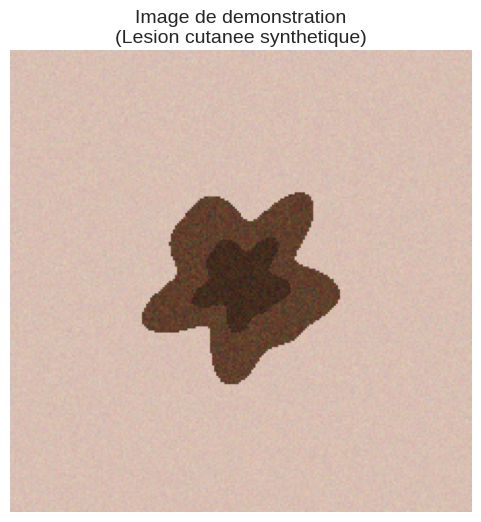

In [ ]:
# ============================================
# IMAGE DE DÉMONSTRATION
# ============================================

def create_demo_image():
    """Creer une image de demonstration simulant une lesion cutanee."""
    np.random.seed(42)

    img = np.ones((224, 224, 3)) * 0.8
    img[:, :, 0] = 0.85
    img[:, :, 1] = 0.75
    img[:, :, 2] = 0.70

    y, x = np.ogrid[:224, :224]
    center_x, center_y = 112, 112
    angles = np.arctan2(y - center_y, x - center_x)
    radius_variation = 40 + 8 * np.sin(5 * angles) + 5 * np.cos(7 * angles)
    distance = np.sqrt((x - center_x)**2 + (y - center_y)**2)
    lesion_mask = distance < radius_variation

    img[lesion_mask, 0] = 0.3 + np.random.rand(lesion_mask.sum()) * 0.15
    img[lesion_mask, 1] = 0.2 + np.random.rand(lesion_mask.sum()) * 0.1
    img[lesion_mask, 2] = 0.15 + np.random.rand(lesion_mask.sum()) * 0.05

    dark_center = distance < (radius_variation * 0.5)
    img[dark_center, :] *= 0.7

    img += np.random.randn(224, 224, 3) * 0.02
    img = np.clip(img, 0, 1)

    return img.astype(np.float32)

def preprocess_image(img_array):
    mean = np.array(IMAGENET_MEAN).reshape(1, 1, 3)
    std = np.array(IMAGENET_STD).reshape(1, 1, 3)
    img_normalized = (img_array - mean) / std
    img_tensor = torch.from_numpy(img_normalized.transpose(2, 0, 1)).float()
    return img_tensor.unsqueeze(0)

demo_image = create_demo_image()
demo_tensor = preprocess_image(demo_image).to(device)

plt.figure(figsize=(6, 6))
plt.imshow(demo_image)
plt.title("Image de demonstration\n(Lesion cutanee synthetique)", fontsize=14)
plt.axis('off')
plt.show()

In [ ]:
# ============================================
# PRÉDICTIONS DES 6 MODÈLES
# ============================================

print("Predictions des 6 modeles:\n")
print("="*70)
print(f"{'Modèle':<20} {'Type':<15} {'Prediction':^10} {'Confiance':>10}")
print("-"*70)

predictions = {}

for name, model in models.items():
    model_type = MODELS_CONFIG[name]['type']
    with torch.no_grad():
        output = model(demo_tensor)
        probs = F.softmax(output, dim=1)
        pred_class = probs.argmax(dim=1).item()
        confidence = probs.max().item()

        predictions[name] = {
            'class': pred_class,
            'confidence': confidence,
            'class_name': CLASS_NAMES[pred_class]
        }

        print(f"{name:<20} {model_type:<15} {CLASS_NAMES[pred_class]:^10} {confidence:>10.1%}")

print("="*70)

Predictions des 6 modeles:

Modèle               Type            Prediction  Confiance
----------------------------------------------------------------------
resnet50             CNN                BCC          13.8%
efficientnet_b4      CNN                 DF          43.5%
convnext_base        CNN-Modern          AK          25.5%
vit_base             Transformer        BKL          26.9%
deit_base            Transformer        BCC          26.6%
swin_base            Transformer        BCC          23.4%


In [ ]:
# ============================================
# GÉNÉRER LES EXPLICATIONS POUR LES 6 MODÈLES
# ============================================

print("Generation des explications XAI pour les 6 modeles...\n")

explanations = {}

for model_name, model in models.items():
    model_type = MODELS_CONFIG[model_name]['type']
    pred_class = predictions[model_name]['class']

    print(f"\n{model_name} ({model_type}):")
    explanations[model_name] = {}

    # Grad-CAM (tous les modeles)
    try:
        gradcam = GradCAMExplainer(model, device)
        explanations[model_name]['GradCAM'] = gradcam.explain(demo_tensor, pred_class)
        print("   ✓ Grad-CAM")
    except Exception as e:
        print(f"   ✗ Grad-CAM: {e}")

    # Integrated Gradients (tous les modeles)
    try:
        ig = IntegratedGradientsExplainer(model, device, n_steps=50)
        explanations[model_name]['IntegratedGradients'] = ig.explain(demo_tensor, pred_class)
        print("   ✓ Integrated Gradients")
    except Exception as e:
        print(f"   ✗ Integrated Gradients: {e}")

    # Attention Rollout (ViT/DeiT uniquement)
    if model_name in ['vit_base', 'deit_base']:
        try:
            attn = AttentionRolloutExplainer(model, device)
            explanations[model_name]['AttentionRollout'] = attn.explain(demo_tensor)
            print("   ✓ Attention Rollout")
        except Exception as e:
            print(f"   ✗ Attention Rollout: {e}")

        # Generic Attention (Chefer)
        try:
            generic = GenericAttentionExplainer(model, device)
            explanations[model_name]['GenericAttention'] = generic.explain(demo_tensor, pred_class)
            print("   ✓ Generic Attention (Chefer)")
        except Exception as e:
            print(f"   ✗ Generic Attention: {e}")

print("\n" + "="*50)
print("Toutes les explications generees!")
print("="*50)

Generation des explications XAI pour les 6 modeles...


resnet50 (CNN):
   ✓ Grad-CAM
   ✓ Integrated Gradients

efficientnet_b4 (CNN):
   ✓ Grad-CAM
   ✓ Integrated Gradients

convnext_base (CNN-Modern):
   ✓ Grad-CAM
   ✓ Integrated Gradients

vit_base (Transformer):
   ✓ Grad-CAM
   ✓ Integrated Gradients
   ✓ Attention Rollout
   ✓ Generic Attention (Chefer)

deit_base (Transformer):
   ✓ Grad-CAM
   ✓ Integrated Gradients
   ✓ Attention Rollout
   ✓ Generic Attention (Chefer)

swin_base (Transformer):
   ✓ Grad-CAM
   ✓ Integrated Gradients

Toutes les explications generees!


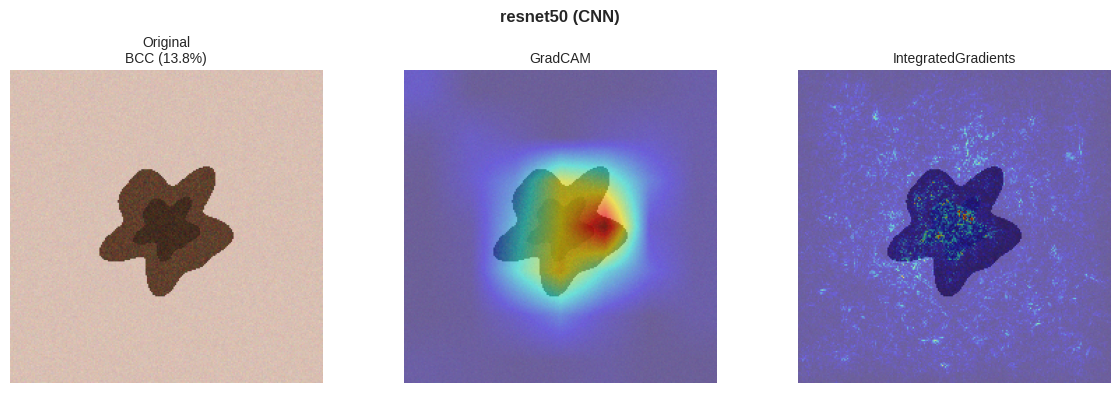

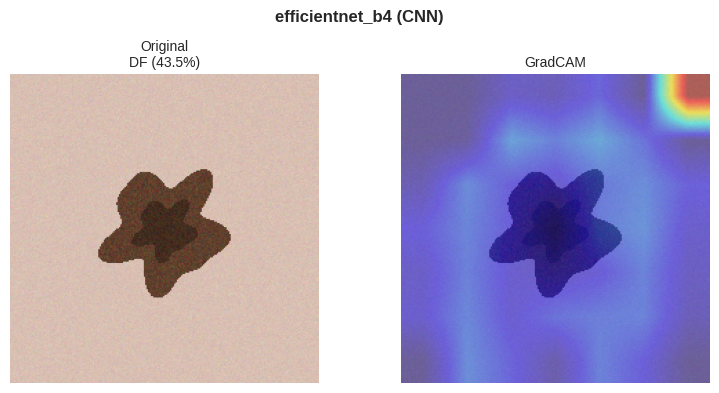

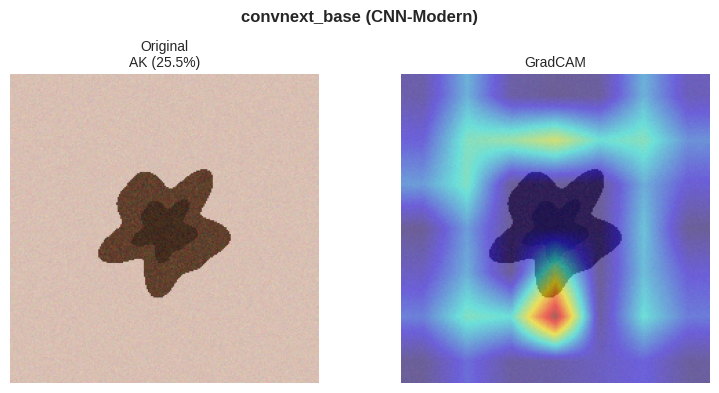

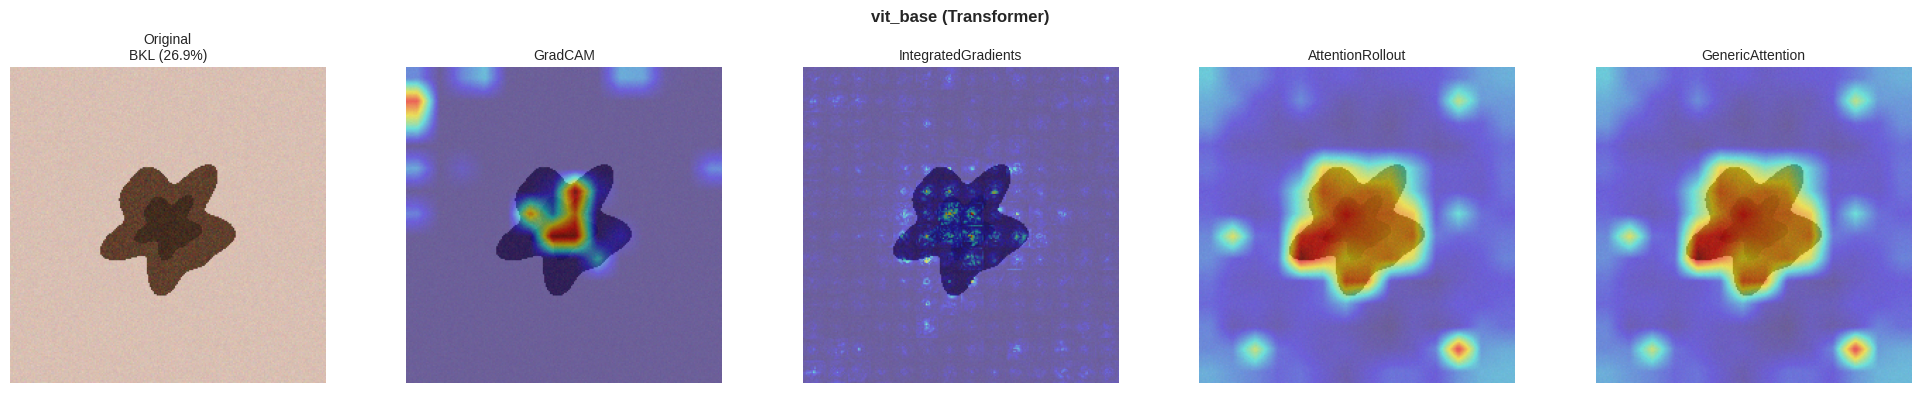

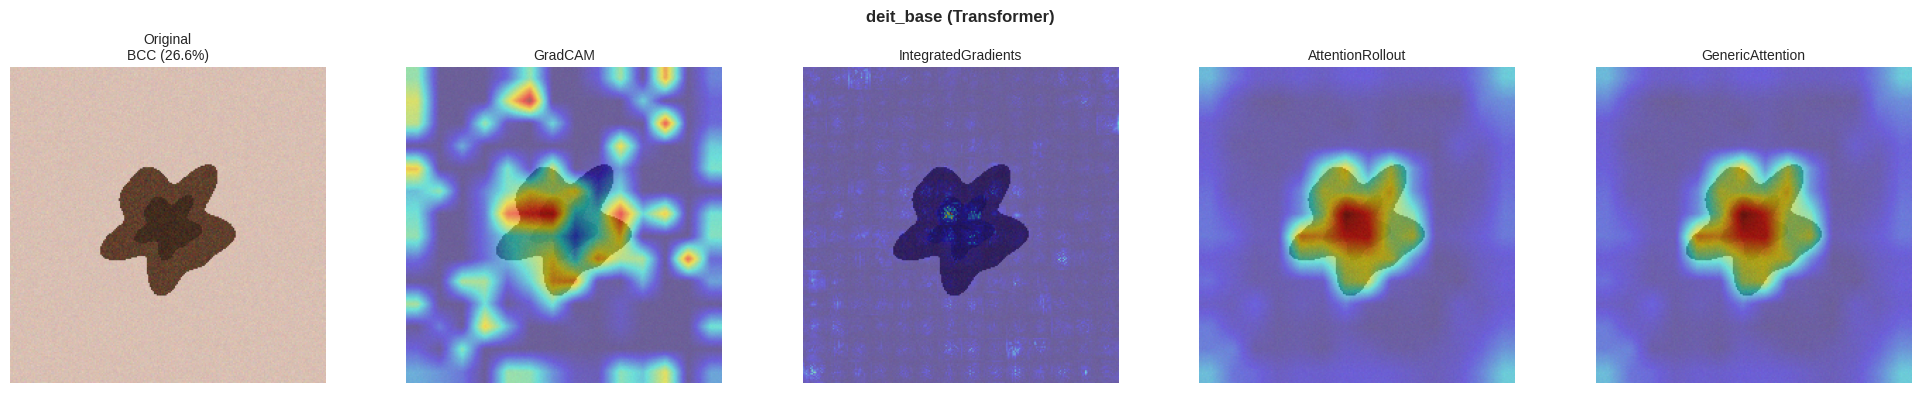

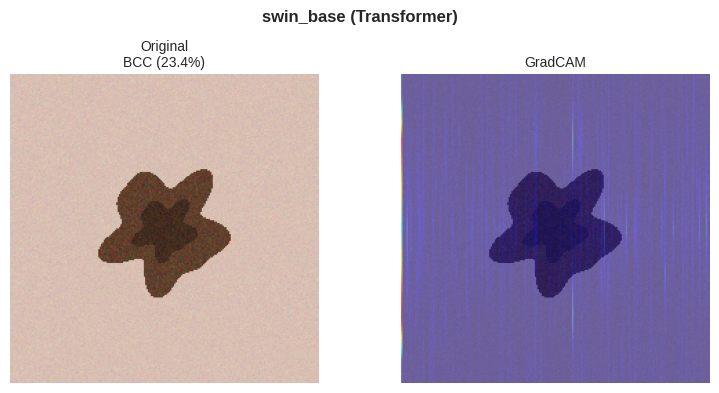

In [ ]:
# ============================================
# VISUALISATION DES 6 MODÈLES
# ============================================

def plot_model_explanations(original_image, explanations, model_name, predictions):
    """Visualiser les explications pour un modele."""
    model_expl = explanations.get(model_name, {})
    num_methods = len(model_expl)
    if num_methods == 0:
        return

    fig, axes = plt.subplots(1, num_methods + 1, figsize=(4 * (num_methods + 1), 4))

    axes[0].imshow(original_image)
    pred = predictions[model_name]
    axes[0].set_title(f"Original\n{pred['class_name']} ({pred['confidence']:.1%})", fontsize=10)
    axes[0].axis('off')

    for idx, (method_name, saliency) in enumerate(model_expl.items()):
        ax = axes[idx + 1]
        if saliency.shape != (224, 224):
            saliency = cv2.resize(saliency, (224, 224))
        heatmap = cv2.applyColorMap(np.uint8(255 * saliency), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        overlay = np.clip(0.5 * heatmap + 0.5 * original_image, 0, 1)
        ax.imshow(overlay)
        ax.set_title(method_name, fontsize=10)
        ax.axis('off')

    plt.suptitle(f"{model_name} ({MODELS_CONFIG[model_name]['type']})", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualiser chaque modele
for model_name in models.keys():
    plot_model_explanations(demo_image, explanations, model_name, predictions)

## 7. Évaluation Quantitative

In [ ]:
# ============================================
# INSERTION / DELETION AUC
# ============================================

def compute_insertion_deletion(model, input_tensor, saliency_map, target_class, num_steps=100, device='cuda'):
    """
    Calculer les scores d'Insertion et Deletion AUC.

    Insertion: Commence avec image masquee, ajoute les pixels importants
    Deletion: Commence avec image complete, retire les pixels importants
    """
    model.eval()
    input_tensor = input_tensor.to(device)

    if saliency_map.shape != (224, 224):
        saliency_map = cv2.resize(saliency_map, (224, 224))

    flat_saliency = saliency_map.flatten()
    sorted_indices = np.argsort(flat_saliency)[::-1]

    # Ensure input_tensor is detached before converting to numpy
    img_np = input_tensor.squeeze().cpu().detach().numpy()
    baseline = np.zeros_like(img_np)

    num_pixels = 224 * 224
    step_size = num_pixels // num_steps

    insertion_scores = []
    deletion_scores = []

    for step in range(num_steps + 1):
        num_reveal = min(step * step_size, num_pixels)

        mask = np.zeros(num_pixels, dtype=bool)
        mask[sorted_indices[:num_reveal]] = True
        mask = mask.reshape(224, 224)

        insertion_img = baseline.copy()
        deletion_img = img_np.copy()
        for c in range(3):
            insertion_img[c][mask] = img_np[c][mask]
            deletion_img[c][mask] = baseline[c][mask]

        with torch.no_grad():
            ins_tensor = torch.from_numpy(insertion_img).unsqueeze(0).float().to(device)
            del_tensor = torch.from_numpy(deletion_img).unsqueeze(0).float().to(device)

            ins_output = F.softmax(model(ins_tensor), dim=1)
            del_output = F.softmax(model(del_tensor), dim=1)

            insertion_scores.append(ins_output[0, target_class].item())
            deletion_scores.append(del_output[0, target_class].item())

    x = np.linspace(0, 1, len(insertion_scores))
    insertion_auc = np.trapz(insertion_scores, x)
    deletion_auc = np.trapz(deletion_scores, x)

    return insertion_auc, deletion_auc, insertion_scores, deletion_scores

print("Fonctions d'evaluation Insertion/Deletion definies")

Fonctions d'evaluation Insertion/Deletion definies


In [ ]:
# ============================================
# ÉVALUER LES MÉTHODES XAI - 6 MODÈLES
# ============================================

print("Evaluation des methodes XAI pour les 6 modeles...\n")

evaluation_results = []

for model_name, model in models.items():
    model_type = MODELS_CONFIG[model_name]['type']
    pred_class = predictions[model_name]['class']
    model_expl = explanations.get(model_name, {})

    print(f"\n{model_name} ({model_type}):")

    for method_name, saliency in model_expl.items():
        try:
            ins_auc, del_auc, _, _ = compute_insertion_deletion(
                model, demo_tensor, saliency, pred_class, device=device
            )
            faithfulness = ins_auc - del_auc

            evaluation_results.append({
                'Model': model_name,
                'Type': model_type,
                'Method': method_name,
                'Insertion AUC': round(ins_auc, 4),
                'Deletion AUC': round(del_auc, 4),
                'Faithfulness': round(faithfulness, 4)
            })
            print(f"   {method_name:25s}: Ins={ins_auc:.3f}, Del={del_auc:.3f}, Faith={faithfulness:.3f}")
        except Exception as e:
            print(f"   {method_name:25s}: Erreur - {e}")

results_df = pd.DataFrame(evaluation_results)
print("\n" + "="*90)
print("TABLEAU RÉCAPITULATIF:")
print("="*90)
print(results_df.to_string(index=False))
print("="*90)

Evaluation des methodes XAI pour les 6 modeles...


resnet50 (CNN):
   GradCAM                  : Ins=0.140, Del=0.127, Faith=0.013
   IntegratedGradients      : Ins=0.136, Del=0.134, Faith=0.002

efficientnet_b4 (CNN):
   GradCAM                  : Ins=0.468, Del=0.372, Faith=0.097
   IntegratedGradients      : Ins=0.339, Del=0.136, Faith=0.203

convnext_base (CNN-Modern):
   GradCAM                  : Ins=0.156, Del=0.140, Faith=0.016
   IntegratedGradients      : Ins=0.235, Del=0.212, Faith=0.023

vit_base (Transformer):
   GradCAM                  : Ins=0.212, Del=0.144, Faith=0.067
   IntegratedGradients      : Ins=0.202, Del=0.153, Faith=0.049
   AttentionRollout         : Ins=0.131, Del=0.132, Faith=-0.001
   GenericAttention         : Ins=0.131, Del=0.132, Faith=-0.002

deit_base (Transformer):
   GradCAM                  : Ins=0.173, Del=0.155, Faith=0.018
   IntegratedGradients      : Ins=0.166, Del=0.138, Faith=0.028
   AttentionRollout         : Ins=0.176, Del=0.139, Faith=

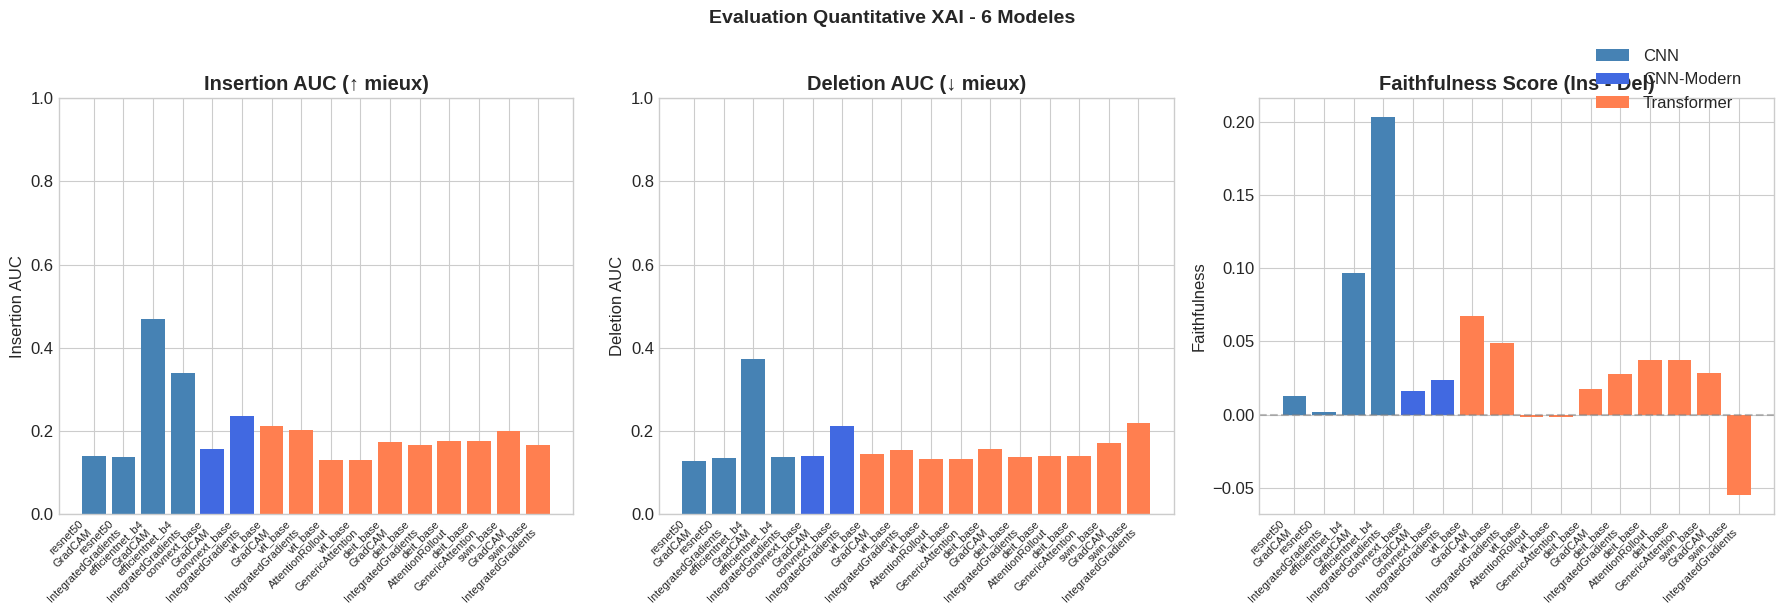

In [ ]:
# ============================================
# VISUALISATION COMPARATIVE - 6 MODÈLES
# ============================================

# Couleurs par type de modele
type_colors = {'CNN': 'steelblue', 'CNN-Modern': 'royalblue', 'Transformer': 'coral'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = [type_colors[r['Type']] for _, r in results_df.iterrows()]

# Insertion AUC
axes[0].bar(range(len(results_df)), results_df['Insertion AUC'], color=colors)
axes[0].set_xticks(range(len(results_df)))
axes[0].set_xticklabels([f"{r['Model']}\n{r['Method']}" for _, r in results_df.iterrows()],
                        rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Insertion AUC')
axes[0].set_title('Insertion AUC (↑ mieux)', fontweight='bold')
axes[0].set_ylim(0, 1)

# Deletion AUC
axes[1].bar(range(len(results_df)), results_df['Deletion AUC'], color=colors)
axes[1].set_xticks(range(len(results_df)))
axes[1].set_xticklabels([f"{r['Model']}\n{r['Method']}" for _, r in results_df.iterrows()],
                        rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Deletion AUC')
axes[1].set_title('Deletion AUC (↓ mieux)', fontweight='bold')
axes[1].set_ylim(0, 1)

# Faithfulness
axes[2].bar(range(len(results_df)), results_df['Faithfulness'], color=colors)
axes[2].set_xticks(range(len(results_df)))
axes[2].set_xticklabels([f"{r['Model']}\n{r['Method']}" for _, r in results_df.iterrows()],
                        rotation=45, ha='right', fontsize=8)
axes[2].set_ylabel('Faithfulness')
axes[2].set_title('Faithfulness Score (Ins - Del)', fontweight='bold')
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in type_colors.items()]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))

plt.suptitle('Evaluation Quantitative XAI - 6 Modeles', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Sanity Checks

In [ ]:
# ============================================
# SANITY CHECKS (Adebayo et al., 2018)
# ============================================

print("Sanity Checks pour les Methodes XAI\n")
print("="*60)
print("Test: Comparer les cartes XAI modele entraine vs aleatoire")
print("Si similaires -> la methode XAI n'est pas fidele au modele")
print("="*60)

# Creer un modele avec poids aleatoires
random_resnet = ModelWrapper('resnet50', NUM_CLASSES, pretrained=False).to(device)
random_resnet.eval()

# Generer Grad-CAM pour les deux modeles
gradcam_trained = GradCAMExplainer(models['resnet50'], device)
gradcam_random = GradCAMExplainer(random_resnet, device)

with torch.no_grad():
    trained_pred = models['resnet50'](demo_tensor).argmax(dim=1).item()
    random_pred = random_resnet(demo_tensor).argmax(dim=1).item()

map_trained = gradcam_trained.explain(demo_tensor, trained_pred)
map_random = gradcam_random.explain(demo_tensor, random_pred)

# Calculer la correlation
correlation = np.corrcoef(map_trained.flatten(), map_random.flatten())[0, 1]

print(f"\nResultat ResNet-50 (Grad-CAM):")
print(f"   Correlation entraine vs aleatoire: {correlation:.3f}")
if abs(correlation) < 0.3:
    print("   Test PASSE: Les cartes sont differentes (methode fidele)")
else:
    print("   Test ECHOUE: Les cartes sont similaires (methode peu fidele)")

Sanity Checks pour les Methodes XAI

Test: Comparer les cartes XAI modele entraine vs aleatoire
Si similaires -> la methode XAI n'est pas fidele au modele

Resultat ResNet-50 (Grad-CAM):
   Correlation entraine vs aleatoire: 0.126
   Test PASSE: Les cartes sont differentes (methode fidele)


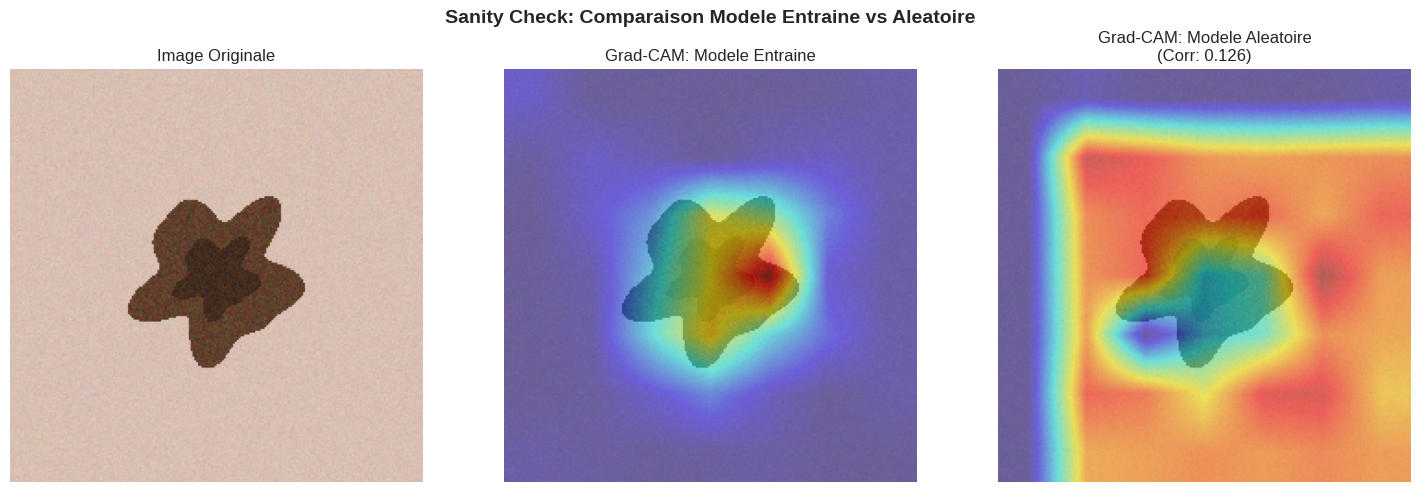

In [ ]:
# Visualisation Sanity Check
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(demo_image)
axes[0].set_title("Image Originale", fontsize=12)
axes[0].axis('off')

heatmap1 = cv2.applyColorMap(np.uint8(255 * cv2.resize(map_trained, (224, 224))), cv2.COLORMAP_JET)
heatmap1 = cv2.cvtColor(heatmap1, cv2.COLOR_BGR2RGB) / 255.0
overlay1 = 0.5 * heatmap1 + 0.5 * demo_image
axes[1].imshow(np.clip(overlay1, 0, 1))
axes[1].set_title("Grad-CAM: Modele Entraine", fontsize=12)
axes[1].axis('off')

heatmap2 = cv2.applyColorMap(np.uint8(255 * cv2.resize(map_random, (224, 224))), cv2.COLORMAP_JET)
heatmap2 = cv2.cvtColor(heatmap2, cv2.COLOR_BGR2RGB) / 255.0
overlay2 = 0.5 * heatmap2 + 0.5 * demo_image
axes[2].imshow(np.clip(overlay2, 0, 1))
axes[2].set_title(f"Grad-CAM: Modele Aleatoire\n(Corr: {correlation:.3f})", fontsize=12)
axes[2].axis('off')

plt.suptitle("Sanity Check: Comparaison Modele Entraine vs Aleatoire", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Résumé

In [ ]:
# ============================================
# RÉSUMÉ - 6 MODÈLES
# ============================================

print("="*70)
print("           RESUME DES RESULTATS - 6 MODELES")
print("="*70)

print("\nMODELES EVALUES:")
print("-"*50)
for name, model in models.items():
    cfg = MODELS_CONFIG[name]
    params = sum(p.numel() for p in model.parameters())
    print(f"   {name:20s} | {cfg['type']:15s} | {params/1e6:.1f}M params")

print("\nMETHODES XAI IMPLEMENTEES:")
print("-"*50)
methods = [
    ("Grad-CAM", "Tous", "Gradient-based"),
    ("Attention Rollout", "ViT/DeiT", "Attention-based"),
    ("Generic Attention (Chefer)", "ViT/DeiT", "Attention + Gradient"),
    ("Integrated Gradients", "Tous", "Gradient-based"),
    ("LIME", "Tous", "Perturbation-based")
]
for method, compat, category in methods:
    print(f"   {method:30s} | {compat:10s} | {category}")

print("\nCLASSEMENT PAR FAITHFULNESS MOYEN:")
print("-"*50)
ranking = results_df.groupby('Model')['Faithfulness'].mean().sort_values(ascending=False)
for i, (model, faith) in enumerate(ranking.items(), 1):
    model_type = MODELS_CONFIG[model]['type']
    emoji = '🥇' if i == 1 else '🥈' if i == 2 else '🥉' if i == 3 else '  '
    print(f"   {emoji} {i}. {model:20s} ({model_type:12s}): {faith:.4f}")

print("\n" + "="*70)

           RESUME DES RESULTATS - 6 MODELES

MODELES EVALUES:
--------------------------------------------------
   resnet50             | CNN             | 23.5M params
   efficientnet_b4      | CNN             | 17.6M params
   convnext_base        | CNN-Modern      | 87.6M params
   vit_base             | Transformer     | 85.8M params
   deit_base            | Transformer     | 85.8M params
   swin_base            | Transformer     | 86.8M params

METHODES XAI IMPLEMENTEES:
--------------------------------------------------
   Grad-CAM                       | Tous       | Gradient-based
   Attention Rollout              | ViT/DeiT   | Attention-based
   Generic Attention (Chefer)     | ViT/DeiT   | Attention + Gradient
   Integrated Gradients           | Tous       | Gradient-based
   LIME                           | Tous       | Perturbation-based

CLASSEMENT PAR FAITHFULNESS MOYEN:
--------------------------------------------------
   🥇 1. efficientnet_b4      (CNN         ): 0.1

## 10. Entraînement avec Techniques Anti-Overfitting

### Problème Résolu: Overfitting sur ISIC-2019

Les modèles CNN (ResNet50, EfficientNet-B4, ConvNeXt) présentaient un écart important entre les performances d'entraînement et de validation, ce qui impacte la crédibilité des analyses XAI.

### Solution Implémentée

Basée sur **Gayatri & Aarthy (2023)** - *"Reduction of overfitting on the highly imbalanced ISIC-2019 skin dataset"* + techniques additionnelles:

| Technique | Description | Effet |
|-----------|-------------|-------|
| **Strong Data Augmentation** | Augmentations spécifiques dermoscopie | Prévient la mémorisation |
| **Focal Loss** | Pénalise moins les exemples faciles | Gère le déséquilibre des classes |
| **Label Smoothing** | Lisse les labels (0.1) | Évite la surconfiance |
| **Mixup/CutMix** | Mélange images et labels | Crée des exemples virtuels |
| **LR Warmup** | Montée progressive du LR | Stabilise le début d'entraînement |
| **EMA** | Moyenne mobile des poids | Lisse les mises à jour |
| **Two-Stage LR** | LR backbone < LR head | Préserve les features pré-entraînées |
| **Gradient Clipping** | Limite la norme des gradients | Prévient l'explosion |

### Fichiers Créés

- `utils/anti_overfitting.py` - Module anti-overfitting
- `train_anti_overfit.py` - Script d'entraînement amélioré

In [ ]:
# ============================================
# 10.1 ANTI-OVERFITTING TRAINING MODULE
# ============================================
# Based on Gayatri & Aarthy (2023) + state-of-the-art techniques

import random
from typing import Tuple, Optional
from torch.cuda.amp import GradScaler, autocast
import albumentations as A
from albumentations.pytorch import ToTensorV2
import json as json_lib
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# ============================================
# 1. ENHANCED DATA AUGMENTATION
# ============================================

def get_strong_train_transform(image_size=224):
    """Strong dermoscopy-specific augmentation (Gayatri & Aarthy 2023)."""
    return A.Compose([
        A.RandomResizedCrop(height=image_size, width=image_size,
                           scale=(0.6, 1.0), ratio=(0.75, 1.33), p=1.0),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.15, scale_limit=0.2, rotate_limit=45,
                          border_mode=0, p=0.7),
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3),
            A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        ], p=0.7),
        A.OneOf([
            A.CoarseDropout(max_holes=12, max_height=16, max_width=16,
                           min_holes=4, fill_value=0, p=1.0),
            A.GridDropout(ratio=0.2, p=1.0),
        ], p=0.3),
        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 7)),
            A.MotionBlur(blur_limit=5),
        ], p=0.2),
        A.GaussNoise(var_limit=(10, 50), p=0.3),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ])

def get_val_transform(image_size=224):
    """Standard validation transform."""
    return A.Compose([
        A.Resize(image_size, image_size),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ])

# ============================================
# 2. MIXUP AND CUTMIX REGULARIZATION
# ============================================

class MixupCutmix:
    """Mixup and CutMix regularization."""

    def __init__(self, mixup_alpha=0.4, cutmix_alpha=1.0, prob=0.5, switch_prob=0.5):
        self.mixup_alpha = mixup_alpha
        self.cutmix_alpha = cutmix_alpha
        self.prob = prob
        self.switch_prob = switch_prob

    def __call__(self, images, labels):
        if random.random() > self.prob:
            return images, labels, labels, 1.0

        batch_size = images.size(0)
        indices = torch.randperm(batch_size, device=images.device)

        if random.random() > self.switch_prob:
            lam = np.random.beta(self.mixup_alpha, self.mixup_alpha)
            mixed_images = lam * images + (1 - lam) * images[indices]
        else:
            lam = np.random.beta(self.cutmix_alpha, self.cutmix_alpha)
            H, W = images.size(2), images.size(3)
            cut_rat = np.sqrt(1.0 - lam)
            cut_h, cut_w = int(H * cut_rat), int(W * cut_rat)
            cy, cx = random.randint(0, H), random.randint(0, W)
            y1, y2 = np.clip(cy - cut_h // 2, 0, H), np.clip(cy + cut_h // 2, 0, H)
            x1, x2 = np.clip(cx - cut_w // 2, 0, W), np.clip(cx + cut_w // 2, 0, W)
            mixed_images = images.clone()
            mixed_images[:, :, y1:y2, x1:x2] = images[indices, :, y1:y2, x1:x2]
            lam = 1 - ((y2 - y1) * (x2 - x1)) / (H * W)

        return mixed_images, labels, labels[indices], lam

    @staticmethod
    def mixup_criterion(criterion, pred, labels_a, labels_b, lam):
        return lam * criterion(pred, labels_a) + (1 - lam) * criterion(pred, labels_b)

# ============================================
# 3. FOCAL LOSS FOR CLASS IMBALANCE
# ============================================

class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance."""

    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_weight = (1 - pt) ** self.gamma
        loss = focal_weight * ce_loss

        if self.alpha is not None:
            alpha_t = self.alpha.to(targets.device)[targets]
            loss = alpha_t * loss

        return loss.mean()

# ============================================
# 4. LEARNING RATE SCHEDULER WITH WARMUP
# ============================================

class LinearWarmupCosineAnnealingLR:
    """LR scheduler with warmup followed by cosine annealing."""

    def __init__(self, optimizer, warmup_epochs, max_epochs, warmup_start_lr=1e-6, eta_min=1e-6):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.max_epochs = max_epochs
        self.warmup_start_lr = warmup_start_lr
        self.eta_min = eta_min
        self.base_lrs = [pg['lr'] for pg in optimizer.param_groups]
        self.current_epoch = 0

    def step(self):
        self.current_epoch += 1
        if self.current_epoch <= self.warmup_epochs:
            alpha = self.current_epoch / self.warmup_epochs
            for pg, base_lr in zip(self.optimizer.param_groups, self.base_lrs):
                pg['lr'] = self.warmup_start_lr + alpha * (base_lr - self.warmup_start_lr)
        else:
            progress = (self.current_epoch - self.warmup_epochs) / (self.max_epochs - self.warmup_epochs)
            for pg, base_lr in zip(self.optimizer.param_groups, self.base_lrs):
                pg['lr'] = self.eta_min + 0.5 * (base_lr - self.eta_min) * (1 + np.cos(np.pi * progress))

# ============================================
# 5. EXPONENTIAL MOVING AVERAGE
# ============================================

class EMA:
    """Exponential Moving Average of model weights."""

    def __init__(self, model, decay=0.999):
        self.model = model
        self.decay = decay
        self.shadow = {}
        self.backup = {}
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()

    def update(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.shadow[name].mul_(self.decay).add_(param.data, alpha=1-self.decay)

    def apply_shadow(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.backup[name] = param.data.clone()
                param.data.copy_(self.shadow[name])

    def restore(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                param.data.copy_(self.backup[name])
        self.backup = {}

# ============================================
# 6. ANTI-OVERFITTING CONFIGURATIONS
# ============================================

ANTI_OVERFIT_CONFIG = {
    'resnet50': {
        'timm_name': 'resnet50', 'type': 'CNN',
        'lr': 3e-4, 'backbone_lr': 3e-5, 'batch_size': 32,
        'dropout_rate': 0.4, 'weight_decay': 0.05, 'warmup_epochs': 5,
        'mixup_prob': 0.5, 'focal_gamma': 2.0, 'label_smoothing': 0.1,
    },
    'efficientnet_b4': {
        'timm_name': 'efficientnet_b4', 'type': 'CNN',
        'lr': 2e-4, 'backbone_lr': 2e-5, 'batch_size': 24,
        'dropout_rate': 0.4, 'weight_decay': 0.02, 'warmup_epochs': 5,
        'mixup_prob': 0.5, 'focal_gamma': 2.0, 'label_smoothing': 0.1,
    },
    'convnext_base': {
        'timm_name': 'convnext_base', 'type': 'CNN-Modern',
        'lr': 1e-4, 'backbone_lr': 1e-5, 'batch_size': 16,
        'dropout_rate': 0.3, 'weight_decay': 0.05, 'warmup_epochs': 5,
        'mixup_prob': 0.5, 'focal_gamma': 2.0, 'label_smoothing': 0.1,
    },
    'vit_base': {
        'timm_name': 'vit_base_patch16_224', 'type': 'Transformer',
        'lr': 1e-5, 'backbone_lr': 1e-6, 'batch_size': 16,
        'dropout_rate': 0.1, 'weight_decay': 0.1, 'warmup_epochs': 10,
        'mixup_prob': 0.5, 'focal_gamma': 2.0, 'label_smoothing': 0.1,
    },
    'deit_base': {
        'timm_name': 'deit_base_patch16_224', 'type': 'Transformer',
        'lr': 1e-5, 'backbone_lr': 1e-6, 'batch_size': 16,
        'dropout_rate': 0.0, 'weight_decay': 0.05, 'warmup_epochs': 10,
        'mixup_prob': 0.5, 'focal_gamma': 2.0, 'label_smoothing': 0.1,
    },
    'swin_base': {
        'timm_name': 'swin_base_patch4_window7_224', 'type': 'Transformer',
        'lr': 2e-5, 'backbone_lr': 2e-6, 'batch_size': 16,
        'dropout_rate': 0.2, 'weight_decay': 0.05, 'warmup_epochs': 8,
        'mixup_prob': 0.5, 'focal_gamma': 2.0, 'label_smoothing': 0.1,
    },
}

print("✓ Anti-overfitting module loaded!")
print("\nTechniques disponibles:")
print("  • Strong data augmentation (dermoscopy-specific)")
print("  • Mixup & CutMix regularization")
print("  • Focal Loss with label smoothing")
print("  • Learning rate warmup + cosine annealing")
print("  • Exponential Moving Average (EMA)")
print("  • Two-stage learning rates")

✓ Anti-overfitting module loaded!

Techniques disponibles:
  • Strong data augmentation (dermoscopy-specific)
  • Mixup & CutMix regularization
  • Focal Loss with label smoothing
  • Learning rate warmup + cosine annealing
  • Exponential Moving Average (EMA)
  • Two-stage learning rates


In [ ]:
# ============================================
# 10.2 FONCTION D'ENTRAÎNEMENT ANTI-OVERFITTING
# ============================================

def train_model_anti_overfit(model_name, model, train_loader, val_loader,
                             epochs=50, patience=15, device='cuda'):
    """
    Train model with comprehensive anti-overfitting techniques.

    Techniques:
    - Mixup/CutMix regularization
    - Focal Loss with label smoothing
    - LR warmup + cosine annealing
    - EMA (Exponential Moving Average)
    - Two-stage learning rates
    - Gradient clipping
    """
    config = ANTI_OVERFIT_CONFIG[model_name]

    # Class weights for imbalanced dataset
    class_weights = train_loader.dataset.get_class_weights().to(device)
    print(f"Class weights: {class_weights.cpu().numpy().round(2)}")

    # Focal Loss
    criterion = FocalLoss(
        alpha=class_weights,
        gamma=config['focal_gamma'],
        label_smoothing=config['label_smoothing']
    )

    # Two-stage learning rates
    backbone_params, head_params = [], []
    for name, param in model.named_parameters():
        if any(x in name.lower() for x in ['head', 'fc', 'classifier']):
            head_params.append(param)
        else:
            backbone_params.append(param)

    optimizer = torch.optim.AdamW([
        {'params': backbone_params, 'lr': config['backbone_lr']},
        {'params': head_params, 'lr': config['lr']}
    ], weight_decay=config['weight_decay'])

    # Scheduler with warmup
    scheduler = LinearWarmupCosineAnnealingLR(
        optimizer, warmup_epochs=config['warmup_epochs'], max_epochs=epochs
    )

    # Mixup/CutMix
    mixup = MixupCutmix(mixup_alpha=0.4, cutmix_alpha=1.0, prob=config['mixup_prob'])

    # EMA
    ema = EMA(model, decay=0.999)

    # Mixed precision
    scaler = GradScaler()

    # Tracking
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
               'val_f1': [], 'val_auc': [], 'lr': []}
    best_val_f1, patience_counter = 0.0, 0

    print(f"\n{'='*70}")
    print(f"Training {model_name} with Anti-Overfitting Techniques")
    print(f"{'='*70}")
    print(f"Head LR: {config['lr']}, Backbone LR: {config['backbone_lr']}")
    print(f"Warmup: {config['warmup_epochs']} epochs | Mixup prob: {config['mixup_prob']}")
    print(f"Focal gamma: {config['focal_gamma']} | Label smoothing: {config['label_smoothing']}")
    print(f"{'='*70}\n")

    for epoch in range(1, epochs + 1):
        # ========== TRAINING ==========
        model.train()
        train_loss, all_preds, all_labels = 0.0, [], []

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}")
        for images, labels, _ in pbar:
            images, labels = images.to(device), labels.to(device)

            # Apply Mixup/CutMix
            mixed_images, labels_a, labels_b, lam = mixup(images, labels)

            optimizer.zero_grad()
            with autocast():
                outputs = model(mixed_images)
                if lam < 1.0:
                    loss = MixupCutmix.mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
                else:
                    loss = criterion(outputs, labels_a)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            ema.update()
            train_loss += loss.item()
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        train_loss /= len(train_loader)
        train_acc = accuracy_score(all_labels, all_preds)

        # ========== VALIDATION (EMA weights) ==========
        ema.apply_shadow()
        model.eval()
        val_loss, all_preds, all_labels, all_probs = 0.0, [], [], []

        with torch.no_grad():
            for images, labels, _ in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                all_probs.extend(F.softmax(outputs, dim=1).cpu().numpy())
                all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        ema.restore()

        val_loss /= len(val_loader)
        val_acc = accuracy_score(all_labels, all_preds)
        val_f1 = f1_score(all_labels, all_preds, average='macro')
        try:
            val_auc = roc_auc_score(all_labels, np.array(all_probs), multi_class='ovr', average='macro')
        except:
            val_auc = 0.0

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # Log
        print(f"Epoch {epoch:3d}/{epochs} | "
              f"Train: {train_loss:.4f}/{train_acc:.4f} | "
              f"Val: {val_loss:.4f}/{val_acc:.4f} F1:{val_f1:.4f} AUC:{val_auc:.4f} | "
              f"LR: {current_lr:.2e}")

        # History
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['val_auc'].append(val_auc)
        history['lr'].append(current_lr)

        # Check improvement (F1 for imbalanced data)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            ema.apply_shadow()
            torch.save({
                'epoch': epoch, 'model_state_dict': model.state_dict(),
                'val_acc': val_acc, 'val_f1': val_f1, 'val_auc': val_auc, 'config': config
            }, f'{SAVE_DIR}/{model_name}_best.pth')
            ema.restore()
            print(f"         ★ New best model! F1: {best_val_f1:.4f}")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch}")
            break

    # Save history
    with open(f'{SAVE_DIR}/{model_name}_history.json', 'w') as f:
        json_lib.dump(history, f)

    return history, val_acc, best_val_f1


def evaluate_model(model, loader, criterion, device, num_classes=8):
    """Evaluate model on test set."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels, _ in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            all_probs.extend(F.softmax(outputs, dim=1).cpu().numpy())
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return {
        'accuracy': accuracy_score(all_labels, all_preds),
        'f1_macro': f1_score(all_labels, all_preds, average='macro'),
        'auc_roc': roc_auc_score(all_labels, np.array(all_probs), multi_class='ovr', average='macro')
    }


print("✓ Anti-overfitting training function defined")

✓ Anti-overfitting training function defined


In [ ]:
# ============================================
# 10.3 SETUP: DATA LOADERS WITH ENHANCED AUGMENTATION
# ============================================

if not dataset_available:
    raise ValueError("Dataset ISIC non disponible!")

# Import unified dataset class
sys.path.insert(0, '..')
from data.isic_dataset import ISICDataset

# Configuration
EPOCHS = 50
SAVE_DIR = '../results'
EARLY_STOPPING = 15

os.makedirs(SAVE_DIR, exist_ok=True)

# Create data loaders with weighted sampling using unified ISICDataset
def create_anti_overfit_loaders(model_name):
    """
    Create data loaders with strong augmentation and weighted sampling.

    Uses the unified ISICDataset class with augmentation_strength parameter:
    - 'strong' for training (Gayatri & Aarthy 2023 anti-overfitting augmentation)
    - 'medium' or 'light' are also available if needed
    """
    config = ANTI_OVERFIT_CONFIG[model_name]

    # Use unified ISICDataset with augmentation_strength='strong'
    train_dataset = ISICDataset(
        DATA_DIR, split='train',
        image_size=224,
        use_albumentations=True,
        augmentation_strength='strong',  # Anti-overfitting augmentation
        use_official_test=True
    )
    val_dataset = ISICDataset(
        DATA_DIR, split='val',
        image_size=224,
        use_albumentations=True,
        augmentation_strength='medium',  # Val uses standard transforms regardless
        use_official_test=True
    )
    test_dataset = ISICDataset(
        DATA_DIR, split='test',
        image_size=224,
        use_albumentations=True,
        augmentation_strength='medium',  # Test uses standard transforms regardless
        use_official_test=True
    )

    # Weighted sampling for training (handles class imbalance)
    sample_weights = train_dataset.get_class_weights()[train_dataset.labels]
    sampler = torch.utils.data.WeightedRandomSampler(
        sample_weights, len(train_dataset), replacement=True
    )

    loaders = {
        'train': DataLoader(train_dataset, batch_size=config['batch_size'],
                           sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True),
        'val': DataLoader(val_dataset, batch_size=config['batch_size']*2,
                         shuffle=False, num_workers=NUM_WORKERS),
        'test': DataLoader(test_dataset, batch_size=config['batch_size']*2,
                          shuffle=False, num_workers=NUM_WORKERS)
    }

    print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
    print(f"  Using augmentation_strength='strong' for training (anti-overfitting)")
    return loaders

all_histories = {}
all_test_results = {}

print("✓ Anti-overfit data loaders ready (using unified ISICDataset)!")

✓ Anti-overfit data loaders ready (using unified ISICDataset)!


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [ ]:
# ============================================
# 10.3.1 ENTRAÎNEMENT: ResNet-50 (CNN) - Anti-Overfitting
# ============================================

model_name = 'resnet50'
config = ANTI_OVERFIT_CONFIG[model_name]

print(f"\n{'#'*70}")
print(f"# TRAINING: {model_name.upper()} ({config['type']}) with Anti-Overfitting")
print(f"{'#'*70}")

# Load best model if available
checkpoint_path = os.path.join(SAVE_DIR, f'{model_name}_best.pth')
if os.path.exists(checkpoint_path):
    print(f"Loading best model from {checkpoint_path}")
    models[model_name] = load_trained_model(model_name, checkpoint_path, config)
else:
    print(f"Training from pretrained weights...")

# Create loaders with enhanced augmentation
loaders = create_anti_overfit_loaders(model_name)

# Train with anti-overfitting
history, best_acc, best_f1 = train_model_anti_overfit(
    model_name=model_name,
    model=models[model_name],
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    epochs=EPOCHS,
    patience=EARLY_STOPPING,
    device=device
)
all_histories[model_name] = history

# Test evaluation
print(f"\nTest Set Evaluation...")
test_results = evaluate_model(models[model_name], loaders['test'], None, device)
all_test_results[model_name] = test_results
print(f"TEST: Acc={test_results['accuracy']:.4f} F1={test_results['f1_macro']:.4f} AUC={test_results['auc_roc']:.4f}")

torch.cuda.empty_cache()

In [ ]:
# ============================================
# 10.3.2 ENTRAÎNEMENT: EfficientNet-B4 (CNN) - Anti-Overfitting
# ============================================

model_name = 'efficientnet_b4'
config = ANTI_OVERFIT_CONFIG[model_name]

print(f"\n{'#'*70}")
print(f"# TRAINING: {model_name.upper()} ({config['type']}) with Anti-Overfitting")
print(f"{'#'*70}")

checkpoint_path = os.path.join(SAVE_DIR, f'{model_name}_best.pth')
if os.path.exists(checkpoint_path):
    print(f"Loading best model from {checkpoint_path}")
    models[model_name] = load_trained_model(model_name, checkpoint_path, config)
else:
    print(f"Training from pretrained weights...")

loaders = create_anti_overfit_loaders(model_name)

history, best_acc, best_f1 = train_model_anti_overfit(
    model_name=model_name,
    model=models[model_name],
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    epochs=20,
    patience=EARLY_STOPPING,
    device=device
)
all_histories[model_name] = history

print(f"\nTest Set Evaluation...")
test_results = evaluate_model(models[model_name], loaders['test'], None, device)
all_test_results[model_name] = test_results
print(f"TEST: Acc={test_results['accuracy']:.4f} F1={test_results['f1_macro']:.4f} AUC={test_results['auc_roc']:.4f}")

torch.cuda.empty_cache()


######################################################################
# TRAINING: EFFICIENTNET_B4 (CNN) with Anti-Overfitting
######################################################################
Loading best model from ../results/efficientnet_b4_best.pth
✓ Loaded efficientnet_b4 from ../results/efficientnet_b4_best.pth
   Val Acc: 0.6346
   Val F1: 0.5615
Train: 22797 | Val: 2534 | Test: 8238
  Using augmentation_strength='strong' for training (anti-overfitting)
Class weights: [ 0.7   0.25  0.95  3.65  1.21 13.25 12.5   5.04]

Training efficientnet_b4 with Anti-Overfitting Techniques
Head LR: 0.0002, Backbone LR: 2e-05
Warmup: 5 epochs | Mixup prob: 0.5
Focal gamma: 2.0 | Label smoothing: 0.1



Epoch 1/20:   0%|          | 0/950 [00:00<?, ?it/s]

Epoch   1/20 | Train: 1.3957/0.5645 | Val: 0.4485/0.5620 F1:0.4788 AUC:0.9385 | LR: 4.80e-06
         ★ New best model! F1: 0.4788


Epoch 2/20:   0%|          | 0/950 [00:00<?, ?it/s]

Epoch   2/20 | Train: 1.3386/0.5707 | Val: 0.4328/0.5762 F1:0.4911 AUC:0.9389 | LR: 8.60e-06
         ★ New best model! F1: 0.4911


...

Epoch  18/20 | Train: 1.1650/0.6196 | Val: 0.3641/0.6310 F1:0.5627 AUC:0.9486 | LR: 1.82e-06


Epoch 19/20:   0%|          | 0/950 [00:00<?, ?it/s]

Epoch  19/20 | Train: 1.1088/0.6275 | Val: 0.3374/0.6622 F1:0.6142 AUC:0.9530 | LR: 1.21e-06
         ★ New best model! F1: 0.6142


Epoch 20/20:   0%|          | 0/950 [00:00<?, ?it/s]

Epoch  20/20 | Train: 1.2896/0.5971 | Val: 0.3441/0.6586 F1:0.5919 AUC:0.9514 | LR: 1.00e-06

Test Set Evaluation...
TEST: Acc=0.4683 F1=0.3876 AUC=0.8460


In [ ]:
# ============================================
# 10.3.3 ENTRAÎNEMENT: ConvNeXt-Base (CNN-Modern) - Anti-Overfitting
# ============================================

model_name = 'convnext_base'
config = ANTI_OVERFIT_CONFIG[model_name]

print(f"\n{'#'*70}")
print(f"# TRAINING: {model_name.upper()} ({config['type']}) with Anti-Overfitting")
print(f"{'#'*70}")

checkpoint_path = os.path.join(SAVE_DIR, f'{model_name}_best.pth')
if os.path.exists(checkpoint_path):
    print(f"Loading best model from {checkpoint_path}")
    models[model_name] = load_trained_model(model_name, checkpoint_path, config)
else:
    print(f"Training from pretrained weights...")

loaders = create_anti_overfit_loaders(model_name)

history, best_acc, best_f1 = train_model_anti_overfit(
    model_name=model_name,
    model=models[model_name],
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    epochs=EPOCHS,
    patience=EARLY_STOPPING,
    device=device
)
all_histories[model_name] = history

print(f"\nTest Set Evaluation...")
test_results = evaluate_model(models[model_name], loaders['test'], None, device)
all_test_results[model_name] = test_results
print(f"TEST: Acc={test_results['accuracy']:.4f} F1={test_results['f1_macro']:.4f} AUC={test_results['auc_roc']:.4f}")

torch.cuda.empty_cache()

In [ ]:
# ============================================
# 10.3.4 ENTRAÎNEMENT: ViT-Base (Transformer) - Anti-Overfitting
# ============================================

model_name = 'vit_base'
config = ANTI_OVERFIT_CONFIG[model_name]

print(f"\n{'#'*70}")
print(f"# TRAINING: {model_name.upper()} ({config['type']}) with Anti-Overfitting")
print(f"{'#'*70}")

checkpoint_path = os.path.join(SAVE_DIR, f'{model_name}_best.pth')
if os.path.exists(checkpoint_path):
    print(f"Loading best model from {checkpoint_path}")
    models[model_name] = load_trained_model(model_name, checkpoint_path, config)
else:
    print(f"Training from pretrained weights...")

loaders = create_anti_overfit_loaders(model_name)

history, best_acc, best_f1 = train_model_anti_overfit(
    model_name=model_name,
    model=models[model_name],
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    epochs=10,
    patience=EARLY_STOPPING,
    device=device
)
all_histories[model_name] = history

print(f"\nTest Set Evaluation...")
test_results = evaluate_model(models[model_name], loaders['test'], None, device)
all_test_results[model_name] = test_results
print(f"TEST: Acc={test_results['accuracy']:.4f} F1={test_results['f1_macro']:.4f} AUC={test_results['auc_roc']:.4f}")

torch.cuda.empty_cache()


######################################################################
# TRAINING: VIT_BASE (Transformer) with Anti-Overfitting
######################################################################
Loading best model from ../results/vit_base_best.pth
✓ Loaded vit_base from ../results/vit_base_best.pth
   Val Acc: 0.8761
   Val F1: 0.8579
Train: 22797 | Val: 2534 | Test: 8238
  Using augmentation_strength='strong' for training (anti-overfitting)
Class weights: [ 0.7   0.25  0.95  3.65  1.21 13.25 12.5   5.04]

Training vit_base with Anti-Overfitting Techniques
Head LR: 1e-05, Backbone LR: 1e-06
Warmup: 10 epochs | Mixup prob: 0.5
Focal gamma: 2.0 | Label smoothing: 0.1



Epoch 1/10:   0%|          | 0/1425 [00:00<?, ?it/s]

Epoch   1/10 | Train: 0.5702/0.7684 | Val: 0.2532/0.8666 F1:0.8653 AUC:0.9827 | LR: 1.00e-06
         ★ New best model! F1: 0.8653


Epoch 2/10:   0%|          | 0/1425 [00:00<?, ?it/s]

Epoch   2/10 | Train: 0.5577/0.7682 | Val: 0.2558/0.8753 F1:0.8621 AUC:0.9814 | LR: 1.00e-06


...

Epoch   8/10 | Train: 0.5230/0.7807 | Val: 0.2625/0.8867 F1:0.8759 AUC:0.9822 | LR: 1.00e-06


Epoch 9/10:   0%|          | 0/1425 [00:00<?, ?it/s]

Epoch   9/10 | Train: 0.5047/0.7776 | Val: 0.2741/0.8836 F1:0.8791 AUC:0.9813 | LR: 1.00e-06


Epoch 10/10:   0%|          | 0/1425 [00:00<?, ?it/s]

Epoch  10/10 | Train: 0.5229/0.7766 | Val: 0.2621/0.8871 F1:0.8708 AUC:0.9836 | LR: 1.00e-06

Test Set Evaluation...
TEST: Acc=0.5577 F1=0.4704 AUC=0.8297


In [ ]:
# ============================================
# 10.3.5 ENTRAÎNEMENT: DeiT-Base (Transformer) - Anti-Overfitting
# ============================================

model_name = 'deit_base'
config = ANTI_OVERFIT_CONFIG[model_name]

print(f"\n{'#'*70}")
print(f"# TRAINING: {model_name.upper()} ({config['type']}) with Anti-Overfitting")
print(f"{'#'*70}")

checkpoint_path = os.path.join(SAVE_DIR, f'{model_name}_best.pth')
if os.path.exists(checkpoint_path):
    print(f"Loading best model from {checkpoint_path}")
    models[model_name] = load_trained_model(model_name, checkpoint_path, config)
else:
    print(f"Training from pretrained weights...")

loaders = create_anti_overfit_loaders(model_name)

history, best_acc, best_f1 = train_model_anti_overfit(
    model_name=model_name,
    model=models[model_name],
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    epochs=EPOCHS,
    patience=EARLY_STOPPING,
    device=device
)
all_histories[model_name] = history

print(f"\nTest Set Evaluation...")
test_results = evaluate_model(models[model_name], loaders['test'], None, device)
all_test_results[model_name] = test_results
print(f"TEST: Acc={test_results['accuracy']:.4f} F1={test_results['f1_macro']:.4f} AUC={test_results['auc_roc']:.4f}")

torch.cuda.empty_cache()


######################################################################
# TRAINING: DEIT_BASE (Transformer) with Anti-Overfitting
######################################################################
Training from pretrained weights...
Train: 22797 | Val: 2534 | Test: 8238
  Using augmentation_strength='strong' for training (anti-overfitting)
Class weights: [ 0.7   0.25  0.95  3.65  1.21 13.25 12.5   5.04]

Training deit_base with Anti-Overfitting Techniques
Head LR: 1e-05, Backbone LR: 1e-06
Warmup: 10 epochs | Mixup prob: 0.5
Focal gamma: 2.0 | Label smoothing: 0.1



Epoch 1/50:   0%|          | 0/1425 [00:00<?, ?it/s]

Epoch   1/50 | Train: 2.6864/0.3390 | Val: 1.1580/0.1117 F1:0.1330 AUC:0.8286 | LR: 1.00e-06
         ★ New best model! F1: 0.1330


Epoch 2/50:   0%|          | 0/1425 [00:00<?, ?it/s]

Epoch   2/50 | Train: 1.8506/0.4571 | Val: 0.8235/0.2593 F1:0.2411 AUC:0.8790 | LR: 1.00e-06
         ★ New best model! F1: 0.2411


...

Epoch  48/50 | Train: 0.6083/0.7399 | Val: 0.2832/0.8031 F1:0.8035 AUC:0.9764 | LR: 1.00e-06


Epoch 49/50:   0%|          | 0/1425 [00:00<?, ?it/s]

Epoch  49/50 | Train: 0.5866/0.7538 | Val: 0.2785/0.8058 F1:0.8000 AUC:0.9768 | LR: 1.00e-06


Epoch 50/50:   0%|          | 0/1425 [00:00<?, ?it/s]

Epoch  50/50 | Train: 0.5650/0.7558 | Val: 0.2804/0.8051 F1:0.8041 AUC:0.9768 | LR: 1.00e-06

Test Set Evaluation...
TEST: Acc=0.5464 F1=0.4495 AUC=0.8466


In [ ]:
import os
import shutil

def save_results_to_drive():

    source_dir = '/content/xai_medical_imaging/results'

    # Destination directory in Google Drive
    # You can change this path if you want to save it elsewhere in your Drive
    destination_base_dir = '/content/drive/MyDrive'
    destination_folder_name = 'xai_medical_imaging_results'
    destination_dir = os.path.join(destination_base_dir, destination_folder_name)

    # Ensure Google Drive is mounted
    if not os.path.exists('/content/drive'):
        print("Mounting Google Drive...")
        drive.mount('/content/drive')
    else:
        print("Google Drive is already mounted.")

    # Check if the source directory exists
    if not os.path.exists(source_dir):
        print(f"Error: Source directory '{source_dir}' not found. Please ensure results are generated.")
        return

    # Create the destination directory if it doesn't exist
    os.makedirs(destination_base_dir, exist_ok=True)

    # If the destination folder already exists, remove it to ensure a clean copy
    if os.path.exists(destination_dir):
        print(f"Removing existing '{destination_dir}' before copying.")
        shutil.rmtree(destination_dir)

    print(f"Copying '{source_dir}' to '{destination_dir}'...")
    try:
        shutil.copytree(source_dir, destination_dir)
        print("Folder copied successfully to Google Drive!")
    except Exception as e:
        print(f"Error copying folder to Google Drive: {e}")

# Call the function to save results to Google Drive
save_results_to_drive()


Google Drive is already mounted.
Removing existing '/content/drive/MyDrive/xai_medical_imaging_results' before copying.
Copying '/content/xai_medical_imaging/results' to '/content/drive/MyDrive/xai_medical_imaging_results'...
Folder copied successfully to Google Drive!


In [ ]:
# ============================================
# 10.3.6 ENTRAÎNEMENT: Swin-Base (Transformer) - Anti-Overfitting
# ============================================

model_name = 'swin_base'
config = ANTI_OVERFIT_CONFIG[model_name]

print(f"\n{'#'*70}")
print(f"# TRAINING: {model_name.upper()} ({config['type']}) with Anti-Overfitting")
print(f"{'#'*70}")

checkpoint_path = os.path.join(SAVE_DIR, f'{model_name}_best.pth')
if os.path.exists(checkpoint_path):
    print(f"Loading best model from {checkpoint_path}")
    models[model_name] = load_trained_model(model_name, checkpoint_path, config)
else:
    print(f"Training from pretrained weights...")

loaders = create_anti_overfit_loaders(model_name)

history, best_acc, best_f1 = train_model_anti_overfit(
    model_name=model_name,
    model=models[model_name],
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    epochs=EPOCHS,
    patience=EARLY_STOPPING,
    device=device
)
all_histories[model_name] = history

print(f"\nTest Set Evaluation...")
test_results = evaluate_model(models[model_name], loaders['test'], None, device)
all_test_results[model_name] = test_results
print(f"TEST: Acc={test_results['accuracy']:.4f} F1={test_results['f1_macro']:.4f} AUC={test_results['auc_roc']:.4f}")

torch.cuda.empty_cache()

print("\n" + "="*70)
print("✓ Tous les entrainements termines avec Anti-Overfitting!")
print("="*70)


######################################################################
# TRAINING: SWIN_BASE (Transformer) with Anti-Overfitting
######################################################################
Training from pretrained weights...
Train: 22797 | Val: 2534 | Test: 8238
  Using augmentation_strength='strong' for training (anti-overfitting)
Class weights: [ 0.7   0.25  0.95  3.65  1.21 13.25 12.5   5.04]

Training swin_base with Anti-Overfitting Techniques
Head LR: 2e-05, Backbone LR: 2e-06
Warmup: 8 epochs | Mixup prob: 0.5
Focal gamma: 2.0 | Label smoothing: 0.1



Epoch 1/50:   0%|          | 0/1425 [00:00<?, ?it/s]

Epoch   1/50 | Train: 2.4436/0.3889 | Val: 0.9426/0.2167 F1:0.2323 AUC:0.8641 | LR: 1.13e-06
         ★ New best model! F1: 0.2323


Epoch 2/50:   0%|          | 0/1425 [00:00<?, ?it/s]

Epoch   2/50 | Train: 1.6161/0.5198 | Val: 0.6032/0.4558 F1:0.4034 AUC:0.9095 | LR: 1.25e-06
         ★ New best model! F1: 0.4034


...

Epoch  48/50 | Train: 0.5144/0.7593 | Val: 0.2494/0.8571 F1:0.8736 AUC:0.9831 | LR: 1.01e-06


Epoch 49/50:   0%|          | 0/1425 [00:00<?, ?it/s]

Epoch  49/50 | Train: 0.4948/0.7808 | Val: 0.2503/0.8599 F1:0.8754 AUC:0.9834 | LR: 1.00e-06


Epoch 50/50:   0%|          | 0/1425 [00:00<?, ?it/s]

Epoch  50/50 | Train: 0.4916/0.7690 | Val: 0.2471/0.8591 F1:0.8755 AUC:0.9839 | LR: 1.00e-06

Test Set Evaluation...
TEST: Acc=0.5801 F1=0.4933 AUC=0.8476

✓ Tous les entrainements termines avec Anti-Overfitting!


In [ ]:
import os
import shutil

def save_results_to_drive():

    source_dir = '/content/xai_medical_imaging/results'

    # Destination directory in Google Drive
    # You can change this path if you want to save it elsewhere in your Drive
    destination_base_dir = '/content/drive/MyDrive'
    destination_folder_name = 'xai_medical_imaging_results'
    destination_dir = os.path.join(destination_base_dir, destination_folder_name)

    # Ensure Google Drive is mounted
    if not os.path.exists('/content/drive'):
        print("Mounting Google Drive...")
        drive.mount('/content/drive')
    else:
        print("Google Drive is already mounted.")

    # Check if the source directory exists
    if not os.path.exists(source_dir):
        print(f"Error: Source directory '{source_dir}' not found. Please ensure results are generated.")
        return

    # Create the destination directory if it doesn't exist
    os.makedirs(destination_base_dir, exist_ok=True)

    # If the destination folder already exists, remove it to ensure a clean copy
    if os.path.exists(destination_dir):
        print(f"Removing existing '{destination_dir}' before copying.")
        shutil.rmtree(destination_dir)

    print(f"Copying '{source_dir}' to '{destination_dir}'...")
    try:
        shutil.copytree(source_dir, destination_dir)
        print("Folder copied successfully to Google Drive!")
    except Exception as e:
        print(f"Error copying folder to Google Drive: {e}")

# Call the function to save results to Google Drive
save_results_to_drive()


Google Drive is already mounted.
Removing existing '/content/drive/MyDrive/xai_medical_imaging_results' before copying.
Copying '/content/xai_medical_imaging/results' to '/content/drive/MyDrive/xai_medical_imaging_results'...
Folder copied successfully to Google Drive!


In [ ]:
# ============================================
# 10.4 CHARGER DES MODÈLES PRÉ-ENTRAÎNÉS
# ============================================

def load_trained_model(model_name, checkpoint_path, config):
    """Charger un modele depuis un checkpoint."""
    model = ModelWrapper(config['timm_name'], NUM_CLASSES, pretrained=False)

    # Fix for UnpicklingError: Add weights_only=False
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()

    print(f"✓ Loaded {model_name} from {checkpoint_path}")
    print(f"   Val Acc: {checkpoint.get('val_acc', 'N/A'):.4f}")
    print(f"   Val F1: {checkpoint.get('val_f1', 'N/A'):.4f}")

    return model

# Exemple d'utilisation:
print("Pour charger tous les modèles entraînés:")
print("""
for model_name, config in ANTI_OVERFIT_CONFIG.items():
    checkpoint_path = os.path.join(SAVE_DIR, f'{model_name}_best.pth')
    if os.path.exists(checkpoint_path):
        models[model_name] = load_trained_model(model_name, checkpoint_path, config)
""")

Pour charger tous les modèles entraînés:

for model_name, config in ANTI_OVERFIT_CONFIG.items():
    checkpoint_path = os.path.join(SAVE_DIR, f'{model_name}_best.pth')
    if os.path.exists(checkpoint_path):
        models[model_name] = load_trained_model(model_name, checkpoint_path, config)



Loading all best trained models...
✓ Loaded efficientnet_b4 from ../results/efficientnet_b4_best.pth
   Val Acc: 0.6622
   Val F1: 0.6142
✓ Loaded vit_base from ../results/vit_base_best.pth
   Val Acc: 0.8907
   Val F1: 0.8878
✓ Loaded deit_base from ../results/deit_base_best.pth
   Val Acc: 0.8090
   Val F1: 0.8114
✓ Loaded swin_base from ../results/swin_base_best.pth
   Val Acc: 0.8611
   Val F1: 0.8797

Regenerating XAI explanations for loaded models...
   ✗ efficientnet_b4 Integrated Gradients: CUDA out of memory. Tried to allocate 16.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 15.81 MiB is free. Including non-PyTorch memory, this process has 14.54 GiB memory in use. Of the allocated memory 14.06 GiB is allocated by PyTorch, and 345.14 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/d

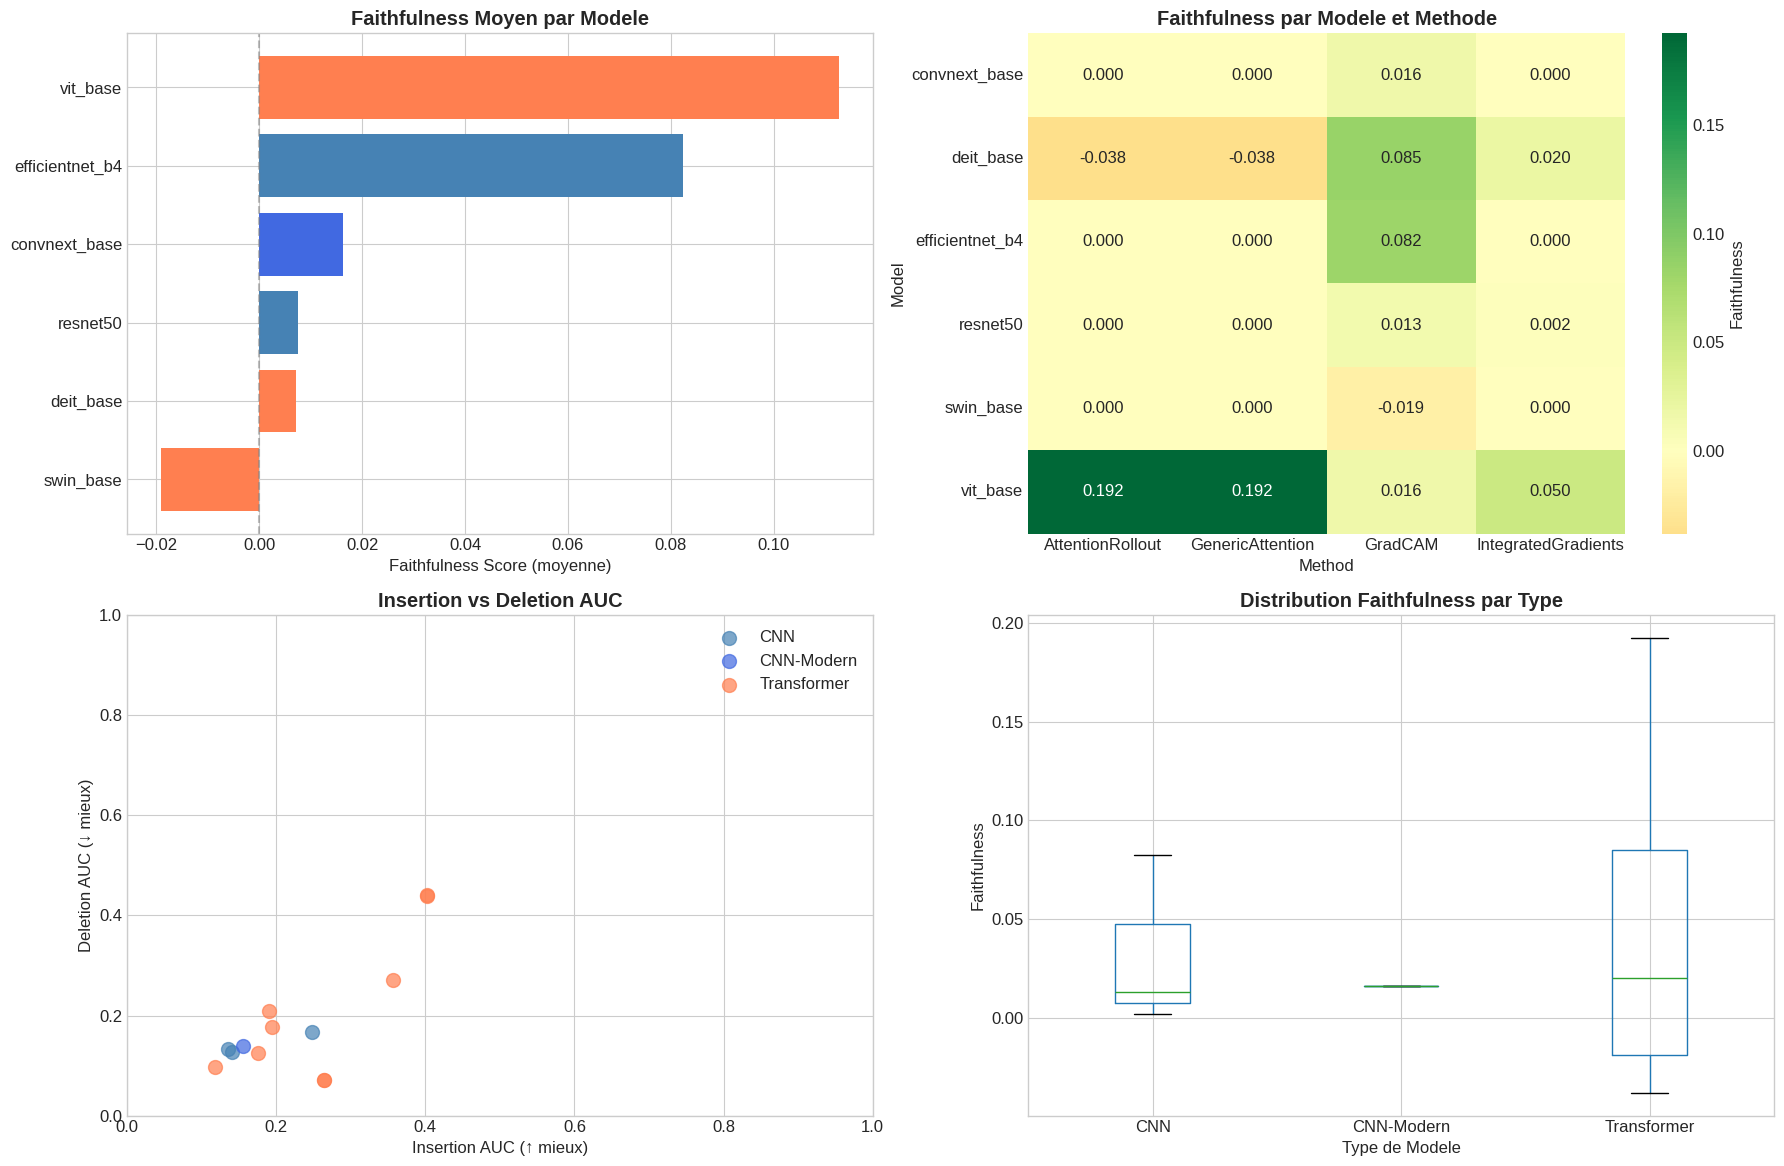


✓ Figure sauvegardee: results/xai_comparison_6_models.png


In [ ]:
# ============================================
# 10.5 VISUALISATION FINALE - 6 MODÈLES
# ============================================

# --- 1. Load all best trained models ---
print("Loading all best trained models...")
for model_name, config in ANTI_OVERFIT_CONFIG.items():
    checkpoint_path = os.path.join(SAVE_DIR, f'{model_name}_best.pth')
    if os.path.exists(checkpoint_path):
        models[model_name] = load_trained_model(model_name, checkpoint_path, config)
    else:
        print(f"Warning: Checkpoint for {model_name} not found at {checkpoint_path}. Skipping.")

# --- 2. Re-generate explanations for the newly loaded models ---
print("\nRegenerating XAI explanations for loaded models...")
explanations = {}
for model_name, model in models.items():
    model_type = ANTI_OVERFIT_CONFIG[model_name]['type']

    # Make a prediction with the loaded model to get the target class
    with torch.no_grad():
        output = model(demo_tensor)
        pred_class = output.argmax(dim=1).item()

    explanations[model_name] = {}

    # Grad-CAM (tous les modeles)
    try:
        gradcam = GradCAMExplainer(model, device)
        explanations[model_name]['GradCAM'] = gradcam.explain(demo_tensor, pred_class)
    except Exception as e:
        print(f"   ✗ {model_name} Grad-CAM: {e}")

    # Integrated Gradients (tous les modeles)
    try:
        ig = IntegratedGradientsExplainer(model, device, n_steps=50)
        explanations[model_name]['IntegratedGradients'] = ig.explain(demo_tensor, pred_class)
    except Exception as e:
        print(f"   ✗ {model_name} Integrated Gradients: {e}")

    # Attention Rollout (ViT/DeiT uniquement)
    if model_name in ['vit_base', 'deit_base', 'swin_base']:
        try:
            attn = AttentionRolloutExplainer(model, device)
            explanations[model_name]['AttentionRollout'] = attn.explain(demo_tensor)
        except Exception as e:
            print(f"   ✗ {model_name} Attention Rollout: {e}")

        # Generic Attention (Chefer)
        try:
            generic = GenericAttentionExplainer(model, device)
            explanations[model_name]['GenericAttention'] = generic.explain(demo_tensor, pred_class)
        except Exception as e:
            print(f"   ✗ {model_name} Generic Attention (Chefer): {e}")


# --- 3. Recalculate Quantitative Evaluation for all models ---
print("\nRecalculating quantitative evaluations...")
new_evaluation_results = []

for model_name, model in models.items():
    model_type = ANTI_OVERFIT_CONFIG[model_name]['type']

    # Make a prediction with the loaded model to get the target class
    with torch.no_grad():
        output = model(demo_tensor)
        pred_class = output.argmax(dim=1).item()

    model_expl = explanations.get(model_name, {})

    for method_name, saliency in model_expl.items():
        try:
            ins_auc, del_auc, _, _ = compute_insertion_deletion(
                model, demo_tensor, saliency, pred_class, device=device
            )
            faithfulness = ins_auc - del_auc

            new_evaluation_results.append({
                'Model': model_name,
                'Type': model_type,
                'Method': method_name,
                'Insertion_AUC': round(ins_auc, 4),
                'Deletion_AUC': round(del_auc, 4),
                'Faithfulness': round(faithfulness, 4)
            })
        except Exception as e:
            print(f"   ✗ {model_name} {method_name}: Error - {e}")

# --- 4. Create full_results_df ---
full_results_df = pd.DataFrame(new_evaluation_results)

print("\n--- Quantitative Evaluation Results (Anti-Overfitting Models) ---")
print(full_results_df.to_string(index=False))


# --- 5. Visualisation (Original Plotting Code) ---

# Couleurs par type de modele
type_colors = {'CNN': 'steelblue', 'CNN-Modern': 'royalblue', 'Transformer': 'coral'}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Make sure colors match the new DataFrame indices after filtering/sorting
colors = [type_colors[ANTI_OVERFIT_CONFIG[r['Model']]['type']] for _, r in full_results_df.iterrows()]

# 1. Faithfulness moyen par modele
ax1 = axes[0, 0]
mean_faith = full_results_df.groupby('Model')['Faithfulness'].mean().sort_values(ascending=True)
colors_mean = [type_colors[ANTI_OVERFIT_CONFIG[m]['type']] for m in mean_faith.index]
bars = ax1.barh(range(len(mean_faith)), mean_faith.values, color=colors_mean)
ax1.set_yticks(range(len(mean_faith)))
ax1.set_yticklabels(mean_faith.index)
ax1.set_xlabel('Faithfulness Score (moyenne)')
ax1.set_title('Faithfulness Moyen par Modele', fontweight='bold')
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# 2. Heatmap
ax2 = axes[0, 1]
pivot = full_results_df.pivot_table(index='Model', columns='Method', values='Faithfulness').fillna(0)
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0, ax=ax2, cbar_kws={'label': 'Faithfulness'})
ax2.set_title('Faithfulness par Modele et Methode', fontweight='bold')

# 3. Insertion AUC par type
ax3 = axes[1, 0]
for model_type in ['CNN', 'CNN-Modern', 'Transformer']:
    subset = full_results_df[full_results_df['Type'] == model_type]
    if not subset.empty:
        ax3.scatter(subset['Insertion_AUC'], subset['Deletion_AUC'],
                   label=model_type, c=type_colors[model_type], s=100, alpha=0.7)
ax3.set_xlabel('Insertion AUC (↑ mieux)')
ax3.set_ylabel('Deletion AUC (↓ mieux)')
ax3.set_title('Insertion vs Deletion AUC', fontweight='bold')
ax3.legend()
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)

# 4. Box plot par type de modele
ax4 = axes[1, 1]
full_results_df.boxplot(column='Faithfulness', by='Type', ax=ax4)
ax4.set_title('Distribution Faithfulness par Type', fontweight='bold')
ax4.set_xlabel('Type de Modele')
ax4.set_ylabel('Faithfulness')
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.savefig('../results/xai_comparison_6_models.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure sauvegardee: results/xai_comparison_6_models.png")

In [ ]:
# ============================================
# 10.6 RÉSUMÉ FINAL ET EXPORT
# ============================================

print("\n" + "="*70)
print("           RÉSUMÉ FINAL - 6 MODÈLES (Anti-Overfitting)")
print("="*70)

print("\n📊 MODÈLES ÉVALUÉS:")
print("-"*50)
for name in models.keys():
    cfg = ANTI_OVERFIT_CONFIG[name]
    params = sum(p.numel() for p in models[name].parameters())
    print(f"   {name:20s} | {cfg['type']:15s} | {params/1e6:.1f}M params")

print("\n🔬 MÉTHODES XAI TESTÉES:")
print("-"*50)
methods_tested = full_results_df['Method'].unique()
for m in sorted(methods_tested):
    print(f"   • {m}")

print("\n🏆 CLASSEMENT PAR FAITHFULNESS:")
print("-"*50)
ranking = full_results_df.groupby('Model')['Faithfulness'].mean().sort_values(ascending=False)
for i, (model, faith) in enumerate(ranking.items(), 1):
    model_type = ANTI_OVERFIT_CONFIG[model]['type']
    emoji = '🥇' if i == 1 else '🥈' if i == 2 else '🥉' if i == 3 else '  '
    print(f"   {emoji} {i}. {model:20s} ({model_type:12s}): {faith:.4f}")

print("\n📈 MEILLEURE MÉTHODE PAR MODÈLE:")
print("-"*50)
best_methods = full_results_df.loc[full_results_df.groupby('Model')['Faithfulness'].idxmax()]
for _, row in best_methods.iterrows():
    print(f"   {row['Model']:20s}: {row['Method']:20s} ({row['Faithfulness']:.4f})")

print("\n" + "="*70)
print("✓ Évaluation complete terminee!")
print("="*70)

# Sauvegarder les resultats
os.makedirs('../results', exist_ok=True)
full_results_df.to_csv('../results/xai_6_models_results.csv', index=False)
print("\n✓ Resultats sauvegardes: results/xai_6_models_results.csv")


           RÉSUMÉ FINAL - 6 MODÈLES (Anti-Overfitting)

📊 MODÈLES ÉVALUÉS:
--------------------------------------------------
   resnet50             | CNN             | 23.5M params
   efficientnet_b4      | CNN             | 17.6M params
   convnext_base        | CNN-Modern      | 87.6M params
   vit_base             | Transformer     | 85.8M params
   deit_base            | Transformer     | 85.8M params
   swin_base            | Transformer     | 86.8M params

🔬 MÉTHODES XAI TESTÉES:
--------------------------------------------------
   • AttentionRollout
   • GenericAttention
   • GradCAM
   • IntegratedGradients

🏆 CLASSEMENT PAR FAITHFULNESS:
--------------------------------------------------
   🥇 1. vit_base             (Transformer ): 0.1127
   🥈 2. efficientnet_b4      (CNN         ): 0.0823
   🥉 3. deit_base            (Transformer ): 0.0299
      4. swin_base            (Transformer ): 0.0285
      5. convnext_base        (CNN-Modern  ): 0.0162
      6. resnet50           

# Task
Okay, I'll add the Git save and push code to your notebook.

Create a new code cell at the end of the notebook containing a function `save_changes_to_git`. This function will:
1. Configure Git user email and name (placeholders will be provided for user modification).
2. Stage changes to `xai_medical_imaging/data/isic_dataset.py`.
3. Stage any new or modified files in the `../results/` directory (where models are saved).
4. Commit these changes with a descriptive message.
5. Push the commit to the `origin` remote on the `main` branch. Instructions for providing credentials will be included.
Then, inform the user that the Git saving and pushing code has been added, and guide them on how to use it, including setting up Git user info and handling authentication for `git push`.

## Add Git save and push code

### Subtask:
Create a new code cell at the end of the notebook containing a function `save_changes_to_git` that handles Git configuration, staging, committing, and pushing.


In [ ]:
cd ..

In [ ]:
!git status

In [ ]:
!git add data/isic_dataset.py

In [ ]:
!git remote set-url origin https://xxxxxxxx@github.com/youssef-nouiouar/xai_medical_imaging.git


In [ ]:
!git push origin main

In [ ]:
cp